# Orbital Data Center: Levelized Cost of Compute (LCOC) Model — v3

**Project:** Feasibility study of whether passive radiative cooling and falling launch costs can make an Orbital Data Center (ODC) cost-competitive with a Terrestrial Data Center (TDC) for AI training workloads.

**Method:** First-principles sizing of PV array and radiator → mass and cost budget → LCOC via Nøland et al. (2024) Eq. 1.

**Model structure (v3, locked initial values):**
- **One** baseline ODC scenario in 2026 — all initial parameter values are now fixed at the spreadsheet values (no high/low scenarios on starting values).
- **One** terrestrial DC scenario for comparison (Nøland et al. baseline).
- **Uncertainty enters only through the learning rate** — three scenarios (Optimistic / Baseline / Pessimistic) that govern how fast each cost component declines (or how fast efficiencies grow). This produces the shaded uncertainty bands on time-series plots.

**Notebook outline:**
1. Constants and locked architectural assumptions
2. Baseline parameter tables (with sources)
3. Learning rate scenarios (lower bound / baseline / upper bound)
4. Physical sizing (PV, radiator, mass)
5. LCOC calculation at year 0 (2026)
6. Terrestrial DC baseline
7. Time projection 2026–2045 across learning rate scenarios
8. Visualizations (LCOC vs time, tornado, LCOC vs launch cost)
9. Summary

## 1. Constants and locked architectural assumptions

**Locked architecture (no variation across scenarios):**
- 100 MW compute payload, training workload, 100% utilization
- MEO at 15,000 km altitude (no eclipse, moderate radiation environment)
- 15-year ODC lifespan, 5-year IT refresh interval (refreshes at year 5 and year 10)
- PV and radiator are one-time launches at year 0 (no refresh)
- Single horizontal radiator beam, double-sided emission, co-located with vertical PV array at mid-height
- Triple-junction GaAs PV cells
- **No OPEX, no structural mass overhead**
- Cooling only the compute module (PV thermally isolated from radiator network)
- Chip temperature 85 °C with a 5 °C chip-to-radiator drop → radiator at 80 °C
- Radiator edge-on to sun (solar projection ≈ 0 at design point; Σcosθ ≈ 0)
- PV view factor F_PV computed self-consistently from geometry; both radiator faces see equal F_PV (mid-height symmetry)
- No radiator coating degradation (no UV / AO / dust accounting)
- No disposal / decommissioning costs
- No temperature gradient across the radiator (single T_rad everywhere)
- Data drop cost itself negligible 

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from dataclasses import dataclass, replace
from typing import Dict, List
from scipy.optimize import brentq
import warnings
warnings.filterwarnings('ignore')

# ----- Physical constants (from spreadsheet "Earth Effective Temp" source) ----
SIGMA        = 5.67e-8            # Stefan-Boltzmann [W m^-2 K^-4]
I_SUN        = 1361               # Solar constant [W m^-2]   (NASA/SORCE TSI)
T_EARTH_EFF  = 254.15             # Earth effective radiating temp [K] (-19 C)
EARTH_ALBEDO = 0.306              # Earth bond albedo

# ----- Architecture constants ------------------------------------------------
Q_COMPUTE          = 100e6                       # 100 MW compute heat load [W]
LIFETIME_YR        = 15
REFRESH_INTERVAL   = 5                           # IT refresh every 5 yrs
HOURS_PER_YEAR     = 8765.8
SECONDS_PER_YEAR   = HOURS_PER_YEAR * 3600
ORBITAL_ALT_KM     = 15_000                      # MEO (Claudio's CF work)

## 2. Baseline ODC parameters (with sources)

All initial values are locked at the spreadsheet values. The "Learning" column indicates whether the parameter evolves over time under a learning rate (see Section 3) or stays constant for the full 15-year mission.

### 2a. Learning parameters (evolve year-over-year)

These are the cost and efficiency parameters that the learning rate scenarios act on.

| Parameter | Symbol | Value (2026) | Units | Learning | Source |
|---|---|---|---|---|---|
| Compute Efficiency | γ | **6.0** | PFLOPS/kW | ✓ | LCOC Paper (Nøland et al. 2024) |
| Launch Cost | — | **1,500** | $/kg | ✓ | Cost for Space Launch (Falcon Heavy / Starship class) |
| PV BOL Efficiency | η_BOL | **0.32** | — | ✓ | NASA Space PV (triple-junction GaAs) |
| PV Areal Cost | — | **33,000** | $/m² | ✓ | Alibaba space PV pricing (50% wholesale discount applied) |
| Radiator Areal Cost | — | **600** | $/m² | ✓ | BaSO₄ paint: $/kg × kg/m² (1 mm thickness) + Aluminium: $20-30/m²|
| IT Cost Density | — | **23,000,000** | $/MW | ✓ | DC rack pricing (DC Rack 3 & 4 sources) |

### 2b. Fixed parameters (constant over the mission)

These do not evolve in time — either physical constants of the architecture or properties that the project treats as locked.

| Parameter | Symbol | Value | Units | Source |
|---|---|---|---|---|
| PV Derating | — | 0.85 | — | NREL PVWatts Calculator |
| PV Areal Density | — | 1.76 | kg/m² | PV GaAs Triple-Junction datasheet |
| Radiator Areal Density | — | 4.5 | kg/m² | BaSO₄ density at 1 mm thickness |
| IT Mass Density | — | 55,000 | kg/MW | DC Rack & DC Rack 2 sources |
| Radiator spine length | L | 300 | m | Structural shared edge with PV array; H = A_PV/(2L) derived |
| PV Temperature | T_PV | 80 | °C | PV operating temp (typical without active cooling) |
| Radiator Solar Absorptance | α_solar | 0.05 | — | Fan et al. 2025 (Adv. Mater.) — BaSO₄ class coating |
| Radiator IR Emissivity / Absorptance | α_IR | 0.95 | — | Fan et al. 2025 (Adv. Mater.) |
| Discount Rate | r | 0.10 | — | Nøland et al. 2024 LCOC paper baseline |
| Earth View Factor (radiator → Earth) | F_⊕ | 0.10 | — | Claudio's view factor work (geometric, 15,000 km altitude) |
| Radiator Temperature | T_rad | 80 | °C | li2024 chips (T_chip = 85 °C, 5 °C drop) |
| PV IR Emissivity (backside) | ε_PV,back | 0.84 | — | PV GaAs Triple-Junction datasheet |
| Data Drop Mass | — | 1,000 | kg/drop | locked architecture |
| Data Drop Rate | — | 2 | drops/yr | locked architecture |
| ODC Lifespan | n | 15 | yrs | locked architecture |
| IT Compute Refresh Interval | — | 5 | yrs | locked architecture (refreshes at yr 5, 10) |
| ODC Compute Rating | — | 100 | MW | locked architecture |
| Solar Constant | I_⊙ | 1,361 | W/m² | Earth Effective Temp source (NASA TSI) |
| Orbital Altitude | — | 15,000 | km | Claudio's CF work (MEO) |
| Earth Albedo | α_⊕ | 0.306 | — | Earth Effective Temp source |
| Earth Effective Rad Temperature | T_⊕ | −19 | °C (254.15 K) | Earth Effective Temp source |

> **Note:** PV view factor F_PV is not a fixed input — it is computed self-consistently as F₁₂(h, w) by the `size_radiator` solver (see Section 4). Both radiator faces see equal F_PV because the beam sits at mid-height of the array.

### 2c. Other assumptions (qualitative)

- No OPEX
- No structural mass overhead
- No eclipse in MEO
- 100% power conditioning efficiency
- Double-sided radiator emission
- Triple-junction GaAs PV cells (NASA Space PV)
- No PV or radiator refresh — only IT refreshes
- Chip temperature 85 °C, 5 °C chip-to-radiator drop (li2024 chips)
- Radiator edge-on to sun (solar projection ≈ 0 at design point; Σcosθ ≈ 0)
- Cooling only compute module (PV thermally isolated)
- 100% utilization, no downtime
- Single TDC scenario (no optimistic / pessimistic TDC variants)
- No radiator coating degradation (no UV exposure, AO erosion, or space-dust accounting)
- No disposal / decommissioning of ODC or launch vehicles
- No temperature gradient across the radiator (single T_rad)
- Data drop cost negligible (only the launch cost of the return mass counts)

In [20]:
@dataclass
class Scenario:
    name: str
    # Compute
    gamma_PFLOPS_per_kW: float
    # Radiator
    eps_IR: float; alpha_solar_rad: float
    F_earth: float; F_PV: float
    T_rad_C: float; T_chip_C: float; arm_angle_deg: float
    rad_areal_mass: float; rad_areal_cost: float
    L_rad: float          # radiator/PV spine length [m]
    # PV
    pv_eff_BOL: float; pv_derating: float
    T_PV_C: float; eps_PV_back: float
    pv_areal_mass: float; pv_areal_cost: float
    # Compute payload
    it_mass_density: float; it_cost_per_MW: float
    # Launch & data
    launch_cost_per_kg: float
    data_mass_per_drop: float; data_drops_per_year: float; data_fixed_cost: float
    # Financial
    discount_rate: float


# -----------------------------------------------------------------------------
# BASELINE (2026 initial values, locked per spreadsheet)
# -----------------------------------------------------------------------------
BASELINE = Scenario(
    name                = 'Baseline 2026',
    # ---- Learning parameters --------------------------------------------------
    gamma_PFLOPS_per_kW = 6.0,            # PFLOPS/kW   (LCOC Paper)
    launch_cost_per_kg  = 1_500.0,        # $/kg        (Cost for Space Launch)
    pv_eff_BOL          = 0.32,           # -           (NASA Space PV)
    pv_areal_cost       = 33_000.0,       # $/m^2       (Alibaba @ 50% wholesale)
    rad_areal_cost      = 600.0,          # $/m^2       (BaSO4 paint)
    it_cost_per_MW      = 23e6,           # $/MW        (DC Rack 3 & 4)
    # ---- Fixed parameters -----------------------------------------------------
    pv_derating         = 0.85,           # NREL PVWatts
    pv_areal_mass       = 1.76,           # kg/m^2      (PV GaAs TJ datasheet)
    rad_areal_mass      = 4.5,            # kg/m^2      (BaSO4 1 mm)
    it_mass_density     = 55_000.0,       # kg/MW       (DC Rack & DC Rack 2)
    F_PV                = 0.617,          # legacy reference; computed by size_radiator
    T_PV_C              = 31.1,           # PV operating temp
    alpha_solar_rad     = 0.05,           # Fan et al. 2025
    eps_IR              = 0.95,           # Fan et al. 2025
    discount_rate       = 0.10,           # Noland 2024
    F_earth             = 0.10,           # Claudio's view factor work
    T_rad_C             = 80.0,           # li2024 chips
    T_chip_C            = 85.0,           # li2024 chips
    arm_angle_deg       = 45.0,           # legacy; not used in horizontal-beam model
    eps_PV_back         = 0.84,           # PV GaAs TJ datasheet
    L_rad               = 300.0,          # m  structural spine / shared PV edge
    data_mass_per_drop  = 1_000.0,        # kg/drop
    data_drops_per_year = 2.0,            # drops/yr
    data_fixed_cost     = 0.0,            # "data drop cost negligible"
)

print(f'Baseline: gamma = {BASELINE.gamma_PFLOPS_per_kW} PFLOPS/kW,'
      f' launch = ${BASELINE.launch_cost_per_kg:,.0f}/kg,'
      f' alpha_IR = {BASELINE.eps_IR},'
      f' alpha_solar = {BASELINE.alpha_solar_rad},'
      f' L_rad = {BASELINE.L_rad:.0f} m')

Baseline: gamma = 6.0 PFLOPS/kW, launch = $1,500/kg, alpha_IR = 0.95, alpha_solar = 0.05, L_rad = 300 m


## 3. Learning rate scenarios

All future-state uncertainty enters through the learning rates applied to the six "Learning" parameters from Section 2a. The shaded band on time-series plots spans the **Pessimistic ↔ Optimistic** trajectories; the central line uses **Baseline**.

These are time-based annual decline (or growth) rates — a simplification compared to Wright's-Law cumulative-production curves, but transparent and defensible for a class project.

### Learning rate table

| Parameter | Optimistic (upper bound) | **Baseline** | Pessimistic (lower bound) | Justification |
|---|---|---|---|---|
| Launch cost ($/kg)           | **−20%/yr** | **−12%/yr** | **−4%/yr**  | SpaceX historical ~15%/yr; brackets Starship reuse upside / stagnation downside |
| PV areal cost ($/m²)         | −10%/yr     | −6%/yr      | −2%/yr      | Terrestrial PV historical ~10%/yr; space-grade is slower |
| Radiator areal cost ($/m²)   | −6%/yr      | −3%/yr      | −1%/yr      | BaSO₄ paint already low-cost; modest improvement room |
| IT cost ($/MW)               | −14%/yr     | −8%/yr      | −3%/yr      | $/FLOP improvement, slower than raw FLOP performance |
| Compute efficiency γ          | **+22%/yr** | **+15%/yr** | **+7%/yr**  | Historical AI hardware ~25%/yr but slowing as we approach physical limits |
| PV efficiency (absolute pp)   | +0.5 pp/yr  | +0.3 pp/yr  | +0.1 pp/yr  | Capped at 40% (theoretical limit for triple-junction class) |
| Terrestrial DC CAPEX ($/kW)  | −4%/yr      | −2%/yr      | −0.5%/yr    | Mature tech, slow incremental gains |
| Electricity price ($/MWh)    | 0% real     | 0% real     | 0% real     | Flat in real terms |

**Key insight:** γ improvement applies to **both** ODC and TDC (same chips, same efficiency curve), so γ shifts both curves down in parallel. The **gap** between ODC and TDC is driven primarily by launch-cost decline (which helps ODC) vs. terrestrial-CAPEX decline (which helps TDC).

In [21]:
@dataclass
class LearningRates:
    name: str
    launch:       float   # annual decline (fractional, e.g. 0.12 = -12%/yr)
    pv_cost:      float
    rad_cost:     float
    it_cost:      float
    gamma_growth: float   # annual growth (fractional)
    pv_eff_pp:    float   # additive percentage points / yr
    terr_capex:   float
    elec_price:   float = 0.0


LR_OPTIMISTIC = LearningRates(
    name='Optimistic',
    launch=0.20, pv_cost=0.10, rad_cost=0.06, it_cost=0.14,
    gamma_growth=0.22, pv_eff_pp=0.005, terr_capex=0.04,
)
LR_BASELINE = LearningRates(
    name='Baseline',
    launch=0.12, pv_cost=0.06, rad_cost=0.03, it_cost=0.08,
    gamma_growth=0.15, pv_eff_pp=0.003, terr_capex=0.02,
)
LR_PESSIMISTIC = LearningRates(
    name='Pessimistic',
    launch=0.04, pv_cost=0.02, rad_cost=0.01, it_cost=0.03,
    gamma_growth=0.07, pv_eff_pp=0.001, terr_capex=0.005,
)
LR_SCENARIOS = [LR_OPTIMISTIC, LR_BASELINE, LR_PESSIMISTIC]

## 4. Physical sizing

PV area sized to deliver `Q_COMPUTE` after BOL efficiency and derating losses (single-sided, normal incidence assumed):

$$A_{\mathrm{PV}} = \frac{Q_{\mathrm{compute}}}{\eta_{\mathrm{BOL}} \cdot \eta_{\mathrm{derate}} \cdot I_{\odot}}$$

**Radiator** is a single horizontal $W \times L$ beam (double-sided emission), co-located with the vertical PV array at mid-height. The beam sits at the midpoint of the array, so both faces see the **same** PV view factor — the top face sees the upper half of the array and the bottom face sees the lower half:

$$F_{\mathrm{PV}} = F_{12}(h,\,w), \quad h = H/L,\quad w = W/L, \quad H = \frac{A_{\mathrm{PV}}}{2L}$$

Net heat rejection per unit one-face area, summed over both faces (edge-on sun design point, $\Sigma\cos\theta \approx 0$):

$$q_{\mathrm{net}}(w) = 2\varepsilon_r \sigma T_r^4 \;-\; 2\varepsilon_r\varepsilon_{\mathrm{PV}}\,F_{12}(h,w)\,\sigma T_{\mathrm{PV}}^4 \;-\; \varepsilon_r \sigma T_\oplus^4 F_\oplus \;-\; \alpha_s\,a_\oplus\,I_\odot F_\oplus$$

Because $F_{12}$ depends on $w$ and $A = wL^2$, the area is **implicit**. $L$ is fixed by the PV structural spine; `brentq` solves for $w^*$:

$$f(w) = q_{\mathrm{net}}(w)\cdot w L^2 - Q_{\mathrm{chip}} = 0 \implies A_{\mathrm{rad}} = w^* L^2$$

The residual is monotone increasing in $w$ (larger radiator sees less PV, more deep space), guaranteeing a unique root. $F_{12}$ is the Howell/Siegel adjacent perpendicular-rectangle view factor (touching at a shared edge $L$).

(Notation: $\varepsilon_r = \alpha_{\mathrm{IR}}$ is the radiator IR emissivity/absorptance per Kirchhoff's law; used consistently with Fan et al. 2025.)

In [22]:
def F_perp_adjacent(h, w):
    """View factor: horizontal W×L plate → perpendicular L×H plate sharing edge L.
    h = H/L, w = W/L. Howell/Siegel adjacent perpendicular rectangles.
    Verified: F_perp_adjacent(1, 1) ≈ 0.20004."""
    H2W2 = h**2 + w**2
    a = ((1 + h**2) * (1 + w**2)) / (1 + H2W2)
    b = (w**2 * (1 + H2W2)) / ((1 + w**2) * H2W2)
    c = (h**2 * (1 + H2W2)) / ((1 + h**2) * H2W2)
    term = (h * np.arctan(1/h) + w * np.arctan(1/w)
            - np.sqrt(H2W2) * np.arctan(1/np.sqrt(H2W2))
            + 0.25 * np.log(a * b**(w**2) * c**(h**2)))
    return term / (np.pi * w)


def size_pv_array(s: Scenario) -> float:
    return Q_COMPUTE / (s.pv_eff_BOL * s.pv_derating * I_SUN)


def size_radiator(s: Scenario, verbose: bool = False) -> float:
    """Self-consistent radiator area for single horizontal beam (double-sided emission).
    Beam sits at mid-height of vertical PV array; both faces see equal F_PV = F_12(h, w).
    L = s.L_rad is fixed; brentq solves for width ratio w = W/L."""
    T_r  = s.T_rad_C + 273.15
    T_PV = s.T_PV_C  + 273.15
    A_PV = size_pv_array(s)
    H    = A_PV / (2 * s.L_rad)   # PV half-height (array extends H above and below spine)
    h    = H / s.L_rad             # dimensionless aspect ratio
    L    = s.L_rad

    def q_net(w):
        """Net heat rejected per m² of one-face area, both faces summed (W/m²)."""
        F_pv = F_perp_adjacent(h, w)
        # gross 2-sided emission − PV re-absorbed on both faces − Earth IR − Earth albedo
        q_ir = (2*s.eps_IR*SIGMA*T_r**4
                - 2*s.eps_IR*s.eps_PV_back*F_pv*SIGMA*T_PV**4
                - s.eps_IR*SIGMA*T_EARTH_EFF**4*s.F_earth)
        q_alb = s.alpha_solar_rad * EARTH_ALBEDO * I_SUN * s.F_earth
        return q_ir - q_alb

    resid = lambda w: q_net(w) * (w * L**2) - Q_COMPUTE
    w_star = brentq(resid, 1e-4, 1e4)
    A_rad  = w_star * L**2

    if verbose:
        q    = q_net(w_star)
        F_pv = F_perp_adjacent(h, w_star)
        P_emit   = 2*s.eps_IR*SIGMA*T_r**4
        P_PV_abs = 2*s.eps_IR*s.eps_PV_back*F_pv*SIGMA*T_PV**4
        P_earth  = s.eps_IR*SIGMA*T_EARTH_EFF**4*s.F_earth
        P_alb    = s.alpha_solar_rad * EARTH_ALBEDO * I_SUN * s.F_earth
        print(f'  Geometry: L={L:.0f} m, H={H:.1f} m, h={h:.3f}, W={w_star*L:.1f} m (w={w_star:.4f})')
        print(f'  F_PV (per face, both equal): {F_pv:.4f}')
        print(f'  Heat balance (W/m² of one-face area):')
        print(f'    Gross emission (2-sided): +{P_emit:>7.1f}')
        print(f'    PV re-absorbed (2 faces): -{P_PV_abs:>7.1f}')
        print(f'    Earth IR:                 -{P_earth:>7.1f}')
        print(f'    Earth albedo:             -{P_alb:>7.2f}')
        print(f'    Net cooling:              +{q:>7.1f}')
    return A_rad


def mass_budget(s: Scenario) -> Dict[str, float]:
    A_PV  = size_pv_array(s)
    A_rad = size_radiator(s)
    m_PV  = A_PV  * s.pv_areal_mass
    m_rad = A_rad * s.rad_areal_mass
    m_IT  = (Q_COMPUTE / 1e6) * s.it_mass_density
    return {
        'A_PV':     A_PV,
        'A_rad':    A_rad,
        'PV':       m_PV,
        'Radiator': m_rad,
        'IT':       m_IT,
        'Total':    m_PV + m_rad + m_IT,
    }

print(f'Verification: F_perp_adjacent(1, 1) = {F_perp_adjacent(1, 1):.5f}  (expect 0.20004)')
print()
print('Physical sizing (2026 baseline):')
A_PV = size_pv_array(BASELINE)
print(f'  PV array:  {A_PV:>10,.0f} m^2  ({A_PV/5350:.2f} football fields)')
A_rad = size_radiator(BASELINE, verbose=True)
print(f'  Radiator:  {A_rad:>10,.0f} m^2  ({A_rad/5350:.2f} football fields)')

mb = mass_budget(BASELINE)
print('\nMass budget (tonnes):')
for k in ['PV', 'Radiator', 'IT', 'Total']:
    print(f'  {k:10s} {mb[k]/1000:>9,.1f} t')

Verification: F_perp_adjacent(1, 1) = 0.20004  (expect 0.20004)

Physical sizing (2026 baseline):
  PV array:     270,130 m^2  (50.49 football fields)
  Geometry: L=300 m, H=450.2 m, h=1.501, W=229.6 m (w=0.7652)
  F_PV (per face, both equal): 0.2567
  Heat balance (W/m² of one-face area):
    Gross emission (2-sided): + 1675.6
    PV re-absorbed (2 faces): -  199.1
    Earth IR:                 -   22.5
    Earth albedo:             -   2.08
    Net cooling:              + 1452.0
  Radiator:      68,871 m^2  (12.87 football fields)

Mass budget (tonnes):
  PV             475.4 t
  Radiator       309.9 t
  IT           5,500.0 t
  Total        6,285.3 t


## 5. LCOC calculation

Following Nøland et al. (2024) Eq. 1. With $\alpha p k t = 0$ (no electricity cost on-orbit) and $dc = 0$ (no OPEX):

$$ \text{LCOC} = \frac{\sum_i \text{cost}_i / (1+r)^i}{\sum_i \gamma k t / (1+r)^i} $$

Cost streams:
- **Hardware**: PV + radiator + IT at year 0; IT refreshes at years 5 and 10.
- **Launch**: full system mass at year 0; IT-only mass at refresh years.
- **Data**: per-drop return-mass launch cost only (drop fixed cost is taken as negligible per the spreadsheet assumption).

In [23]:
def annual_eflop(s: Scenario, k_load: float = 1.0) -> float:
    """Annual compute output [EFLOP/year]."""
    return (Q_COMPUTE / 1000) * s.gamma_PFLOPS_per_kW / 1000 * SECONDS_PER_YEAR * k_load

def build_cash_flows(s: Scenario) -> Dict[str, np.ndarray]:
    mb = mass_budget(s)
    cost_PV  = mb['A_PV']  * s.pv_areal_cost
    cost_rad = mb['A_rad'] * s.rad_areal_cost
    cost_IT  = (Q_COMPUTE / 1e6) * s.it_cost_per_MW
    launch_year0   = mb['Total'] * s.launch_cost_per_kg
    launch_refresh = mb['IT']    * s.launch_cost_per_kg
    hardware = np.zeros(LIFETIME_YR)
    launch   = np.zeros(LIFETIME_YR)
    data     = np.zeros(LIFETIME_YR)
    hardware[0] = cost_PV + cost_rad + cost_IT
    launch[0]   = launch_year0
    for ry in [5, 10]:
        hardware[ry] += cost_IT
        launch[ry]   += launch_refresh
    cost_per_drop = s.data_fixed_cost + s.data_mass_per_drop * s.launch_cost_per_kg
    data[:] = cost_per_drop * s.data_drops_per_year
    return {'hardware': hardware, 'launch': launch, 'data': data,
            'total': hardware + launch + data}

def calculate_lcoc(s: Scenario) -> Dict[str, float]:
    cf = build_cash_flows(s)
    years = np.arange(LIFETIME_YR)
    annual_compute = np.full(LIFETIME_YR, annual_eflop(s))
    discount = 1.0 / (1 + s.discount_rate)**years
    npv_cost    = (cf['total']     * discount).sum()
    npv_compute = (annual_compute * discount).sum()
    lcoc = npv_cost / npv_compute
    breakdown = {
        'Hardware': (cf['hardware'] * discount).sum() / npv_compute,
        'Launch':   (cf['launch']   * discount).sum() / npv_compute,
        'Data':     (cf['data']     * discount).sum() / npv_compute,
    }
    return {'lcoc': lcoc, 'breakdown': breakdown, 'npv_cost': npv_cost}

baseline_result = calculate_lcoc(BASELINE)
print(f'2026 baseline ODC LCOC:  ${baseline_result["lcoc"]:.4f}/EFLOP')
print(f'NPV of total cost:       ${baseline_result["npv_cost"]/1e9:.2f}B')
print(f'\nCost breakdown:')
for k, v in baseline_result['breakdown'].items():
    print(f'  {k:10s} ${v:.4f}/EFLOP   ({v/baseline_result["lcoc"]*100:5.1f}%)')

2026 baseline ODC LCOC:  $0.1978/EFLOP
NPV of total cost:       $31.33B

Cost breakdown:
  Hardware   $0.0857/EFLOP   ( 43.3%)
  Launch     $0.1119/EFLOP   ( 56.6%)
  Data       $0.0002/EFLOP   (  0.1%)


## 6. Terrestrial DC baseline (Nøland et al. methodology)

Using their Table 5 baseline: $c = \$10{,}000$/kW, $d = 10\%$ (annual OPEX as fraction of CAPEX), $\alpha = 1.12$ (PUE), $p = \$150$/MWh, $r = 10\%$, $n = 15$ years, $k = 1$.

Computed at the **same γ as the ODC baseline** for apples-to-apples comparison.

In [24]:
def terrestrial_lcoc(gamma_PFLOPS_per_kW: float,
                     c_per_kW: float  = 10_000,
                     d_frac: float    = 0.10,
                     alpha_PUE: float = 1.12,
                     p_per_MWh: float = 150,
                     r_wacc: float    = 0.10,
                     n_years: int     = 15,
                     k_load: float    = 1.0) -> float:
    """Noland et al. 2024 Eq. 1 - terrestrial LCOC in $/EFLOP."""
    annual_elec    = alpha_PUE * (p_per_MWh / 1000) * k_load * HOURS_PER_YEAR
    annual_opex    = d_frac * c_per_kW
    annual_compute = gamma_PFLOPS_per_kW * k_load * SECONDS_PER_YEAR
    df = np.array([1/(1+r_wacc)**i for i in range(n_years)])
    npv_costs    = c_per_kW + ((annual_elec + annual_opex) * df).sum()
    npv_compute  = (annual_compute * df).sum()
    return (npv_costs / npv_compute) * 1000   # $/PFLOP -> $/EFLOP

# Sanity check vs. paper-reported value at gamma=0.1
verify = terrestrial_lcoc(0.1)
print(f'Verification @ gamma=0.1: ${verify:.3f}/EFLOP   (Noland 2024 paper baseline: $1.16)')

tdc_baseline = terrestrial_lcoc(BASELINE.gamma_PFLOPS_per_kW)
print(f'\nTDC @ gamma={BASELINE.gamma_PFLOPS_per_kW} PFLOPS/kW: ${tdc_baseline:.4f}/EFLOP')
print(f'ODC / TDC ratio (2026): {baseline_result["lcoc"]/tdc_baseline:.2f}x')

Verification @ gamma=0.1: $1.162/EFLOP   (Noland 2024 paper baseline: $1.16)

TDC @ gamma=6.0 PFLOPS/kW: $0.0194/EFLOP
ODC / TDC ratio (2026): 10.21x


## 7. Time projection 2026–2045

Apply each learning rate scenario to the baseline year over year. Generates three trajectories (Optimistic / Baseline / Pessimistic learning rates) for both ODC and TDC.

In [25]:
def evolve_scenario(s_base: Scenario, year_offset: int, lr: LearningRates) -> Scenario:
    """Return s_base evolved year_offset years into the future under learning rates lr."""
    return replace(s_base,
        gamma_PFLOPS_per_kW = s_base.gamma_PFLOPS_per_kW * (1 + lr.gamma_growth)**year_offset,
        launch_cost_per_kg  = s_base.launch_cost_per_kg  * (1 - lr.launch)**year_offset,
        pv_areal_cost       = s_base.pv_areal_cost       * (1 - lr.pv_cost)**year_offset,
        rad_areal_cost      = s_base.rad_areal_cost      * (1 - lr.rad_cost)**year_offset,
        it_cost_per_MW      = s_base.it_cost_per_MW      * (1 - lr.it_cost)**year_offset,
        pv_eff_BOL          = min(0.40, s_base.pv_eff_BOL + lr.pv_eff_pp * year_offset),
    )

def terrestrial_evolved(gamma_baseline: float, year_offset: int, lr: LearningRates) -> float:
    gamma_t = gamma_baseline * (1 + lr.gamma_growth)**year_offset
    capex_t = 10_000 * (1 - lr.terr_capex)**year_offset
    return terrestrial_lcoc(gamma_t, c_per_kW=capex_t)

# Project each LR scenario forward
START_YEAR, END_YEAR = 2026, 2045
years_calendar = np.arange(START_YEAR, END_YEAR + 1)
year_offsets   = years_calendar - START_YEAR

odc_by_lr: Dict[str, np.ndarray] = {}
tdc_by_lr: Dict[str, np.ndarray] = {}

for lr in LR_SCENARIOS:
    odc_vals, tdc_vals = [], []
    for yo in year_offsets:
        ev = evolve_scenario(BASELINE, yo, lr)
        odc_vals.append(calculate_lcoc(ev)['lcoc'])
        tdc_vals.append(terrestrial_evolved(BASELINE.gamma_PFLOPS_per_kW, yo, lr))
    odc_by_lr[lr.name] = np.array(odc_vals)
    tdc_by_lr[lr.name] = np.array(tdc_vals)

# Convenience aliases
odc_nom = odc_by_lr['Baseline']
odc_hi  = odc_by_lr['Optimistic']     # lower LCOC = cheaper
odc_lo  = odc_by_lr['Pessimistic']    # higher LCOC = more expensive
tdc_nom = tdc_by_lr['Baseline']
tdc_hi  = tdc_by_lr['Optimistic']
tdc_lo  = tdc_by_lr['Pessimistic']

print(f'{"Year":>6s}  {"ODC Base":>10s}  {"ODC Opt":>10s}  {"ODC Pes":>10s}  '
      f'{"TDC Base":>10s}  {"ratio":>8s}')
for label, idx in [('2026', 0), ('2030', 4), ('2035', 9), ('2040', 14), ('2045', 19)]:
    print(f'{label:>6s}  ${odc_nom[idx]:>9.4f}  ${odc_hi[idx]:>9.4f}  '
          f'${odc_lo[idx]:>9.4f}  ${tdc_nom[idx]:>9.4f}  '
          f'{odc_nom[idx]/tdc_nom[idx]:>7.2f}x')

  Year    ODC Base     ODC Opt     ODC Pes    TDC Base     ratio
  2026  $   0.1978  $   0.1978  $   0.1978  $   0.0194    10.21x
  2030  $   0.0747  $   0.0436  $   0.1316  $   0.0106     7.07x
  2035  $   0.0225  $   0.0070  $   0.0792  $   0.0050     4.53x
  2040  $   0.0069  $   0.0012  $   0.0477  $   0.0023     2.95x
  2045  $   0.0022  $   0.0002  $   0.0288  $   0.0011     1.96x


## 8. Visualizations

All plots share a dark-space aesthetic for the project presentation:
- Pure-black background
- Vivid green for ODC, off-white for TDC
- All-white labels and tick marks for readability
- Poppins font where available

In [26]:
# Shared styling constants
BG        = '#08090d'
ODC_COLOR = '#b8f73e'   # vivid spring green
TDC_COLOR = '#F7F8F8'   # bright off-white
ACCENT_R  = '#ff5566'   # red accent for tornado / 'bad' direction
GRID      = '#2a2f40'
WHITE     = '#ffffff'
FONT      = 'Poppins'   # fallback to default if not installed

def _fmt_dollar(x, _):
    if x >= 1:    return f'${x:,.0f}'
    if x >= 0.01: return f'${x:.2f}'
    return f'${x:.4f}'

def style_axes(ax, fig, title, subtitle=None, xlabel=None, ylabel=None,
               y_log=True, x_log=False, ylim=None, xlim=None,
               y_dollar=True, x_dollar=False):
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)
    if y_log: ax.set_yscale('log')
    if x_log: ax.set_xscale('log')
    if ylim: ax.set_ylim(ylim)
    if xlim: ax.set_xlim(xlim)

    ax.grid(True, which='major', color=GRID, alpha=0.5, linewidth=0.6)
    ax.grid(True, which='minor', color=GRID, alpha=0.20, linewidth=0.35)
    ax.set_axisbelow(True)
    for sp in ax.spines.values():
        sp.set_color(GRID); sp.set_linewidth(1.0)

    if y_dollar:
        ax.yaxis.set_major_formatter(FuncFormatter(_fmt_dollar))
    if x_dollar:
        ax.xaxis.set_major_formatter(FuncFormatter(_fmt_dollar))

    ax.tick_params(colors=WHITE, which='both', labelsize=11)
    plt.setp(ax.get_yticklabels(), fontfamily=FONT, color=WHITE)
    plt.setp(ax.get_xticklabels(), fontfamily=FONT, color=WHITE)

    if xlabel:
        ax.set_xlabel(xlabel, fontsize=13, color=WHITE,
                      fontfamily=FONT, labelpad=10, fontweight='medium')
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=13, color=WHITE,
                      fontfamily=FONT, labelpad=10, fontweight='medium')

    ax.set_title(title, fontsize=17, fontfamily=FONT, color=WHITE,
                 pad=18, loc='left', fontweight='bold')
    if subtitle:
        ax.text(0.0, 1.015, subtitle, transform=ax.transAxes,
                fontsize=10, color=WHITE, fontfamily=FONT, alpha=0.85,
                va='bottom', ha='left')

### 8a. LCOC over time (2026 → 2045)

Uncertainty bands span the Pessimistic ↔ Optimistic learning-rate trajectories; the heavy central line is the Baseline learning-rate trajectory.

findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: F

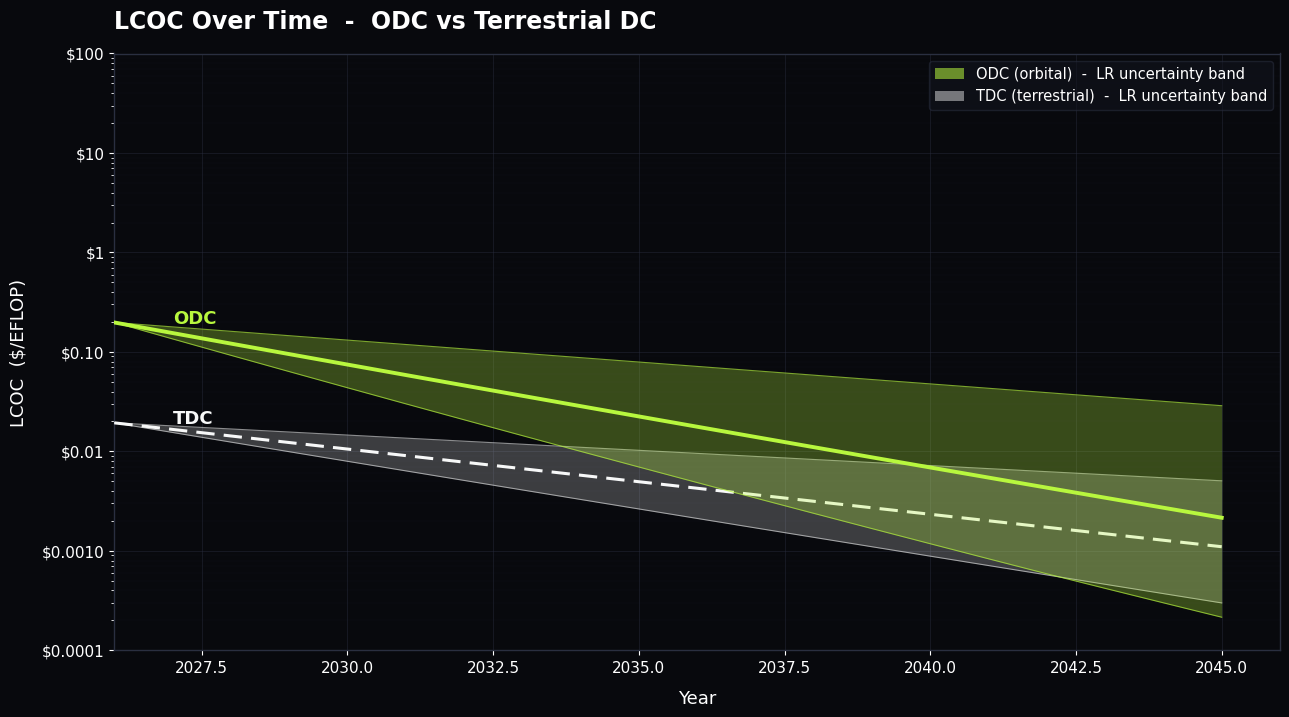

In [27]:
fig, ax = plt.subplots(figsize=(13, 7.5))

# TDC band
ax.fill_between(years_calendar, tdc_lo, tdc_hi, color=TDC_COLOR, alpha=0.22,
                zorder=2, linewidth=0)
ax.plot(years_calendar, tdc_hi, color=TDC_COLOR, linewidth=0.8, alpha=0.55, zorder=3)
ax.plot(years_calendar, tdc_lo, color=TDC_COLOR, linewidth=0.8, alpha=0.55, zorder=3)
ax.plot(years_calendar, tdc_nom, color=TDC_COLOR, linewidth=2.2,
        linestyle=(0,(6,3)), zorder=4)

# ODC band
ax.fill_between(years_calendar, odc_lo, odc_hi, color=ODC_COLOR, alpha=0.28,
                zorder=5, linewidth=0)
ax.plot(years_calendar, odc_hi, color=ODC_COLOR, linewidth=0.8, alpha=0.65, zorder=6)
ax.plot(years_calendar, odc_lo, color=ODC_COLOR, linewidth=0.8, alpha=0.65, zorder=6)
ax.plot(years_calendar, odc_nom, color=ODC_COLOR, linewidth=2.8, zorder=7)

# Crossover annotation (baseline-LR ODC = baseline-LR TDC)
diff = odc_nom - tdc_nom
crosses = np.where(np.diff(np.sign(diff)))[0]
for cx in crosses:
    cy = (odc_nom[cx] + tdc_nom[cx]) / 2
    ax.axvline(years_calendar[cx], color=WHITE, linewidth=0.7,
               linestyle=':', alpha=0.5, zorder=2)
    ax.annotate(f'Breakeven\n{years_calendar[cx]}',
                xy=(years_calendar[cx], cy),
                xytext=(years_calendar[cx]+1.5, cy*4.0),
                fontsize=10, color=WHITE, fontfamily=FONT, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=WHITE, alpha=0.55, lw=0.9))

# End-of-line labels
ax.text(2027, odc_nom[0]*1.1, 'ODC', color=ODC_COLOR, fontfamily=FONT,
        fontsize=13, fontweight='bold', va='center')
ax.text(2027, tdc_nom[0]*1.1, 'TDC', color=TDC_COLOR, fontfamily=FONT,
        fontsize=13, fontweight='bold', va='center')

handles = [
    mpatches.Patch(facecolor=ODC_COLOR, alpha=0.55,
                   label='ODC (orbital)  -  LR uncertainty band'),
    mpatches.Patch(facecolor=TDC_COLOR, alpha=0.45,
                   label='TDC (terrestrial)  -  LR uncertainty band'),
]
leg = ax.legend(handles=handles, loc='upper right', frameon=True,
                framealpha=0.55, edgecolor=GRID,
                facecolor='#12141e', fontsize=10.5,
                prop={'family': FONT, 'size': 10.5})
for t in leg.get_texts(): t.set_color(WHITE)

style_axes(ax, fig,
    title='LCOC Over Time  -  ODC vs Terrestrial DC',
#     subtitle='100 MW MEO  -  15-yr life  -  bands span pessimistic <-> optimistic learning rates  -  2026-2045',
    xlabel='Year',
    ylabel='LCOC  ($/EFLOP)',
    xlim=(2026, 2046),
    ylim=(0.0001, 100),
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### 8b. Tornado sensitivity chart

Each row swings one variable up and down independently around the 2026 baseline and records the resulting LCOC. Rows are sorted by total swing magnitude — variables at the top dominate cost uncertainty. Green = cheaper-LCOC direction; red = more-expensive direction.

findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: F

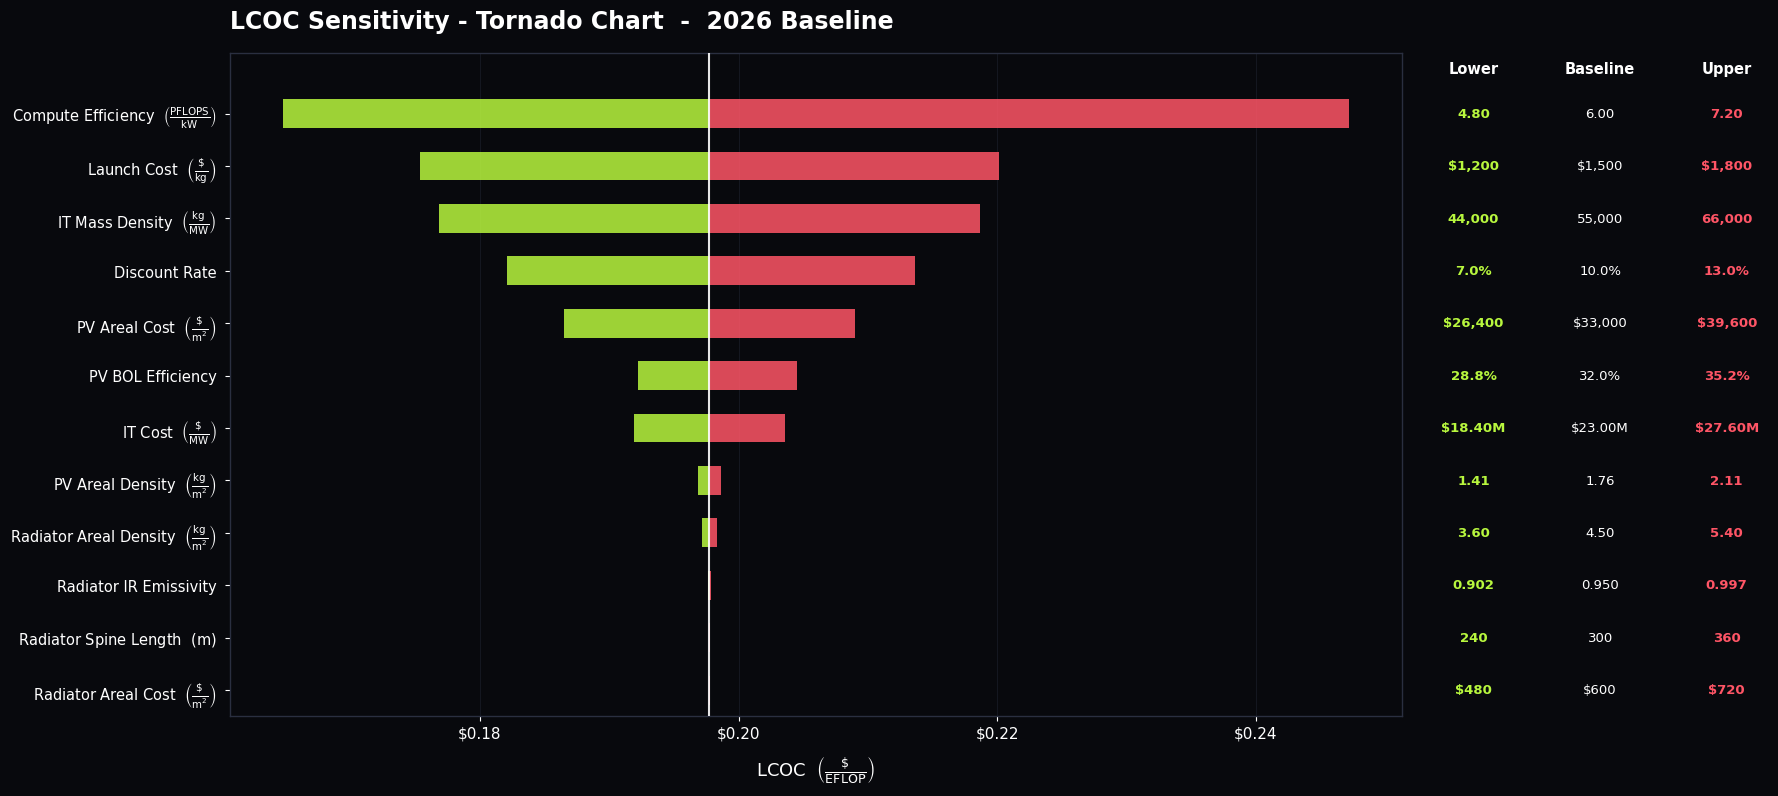

In [28]:
# Parameters to vary, with +/- range
PARAMS_TO_VARY = [
    ('Launch Cost  ' + r'$\left(\frac{\$}{\mathrm{kg}}\right)$',
     'launch_cost_per_kg', 0.20),
    ('Compute Efficiency  ' + r'$\left(\frac{\mathrm{PFLOPS}}{\mathrm{kW}}\right)$',
     'gamma_PFLOPS_per_kW', 0.20),
    ('IT Cost  ' + r'$\left(\frac{\$}{\mathrm{MW}}\right)$',
     'it_cost_per_MW', 0.20),
    ('PV Areal Cost  ' + r'$\left(\frac{\$}{\mathrm{m}^{2}}\right)$',
     'pv_areal_cost', 0.20),
    ('IT Mass Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{MW}}\right)$',
     'it_mass_density', 0.20),
    ('PV Areal Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{m}^{2}}\right)$',
     'pv_areal_mass', 0.20),
    ('Radiator Areal Cost  ' + r'$\left(\frac{\$}{\mathrm{m}^{2}}\right)$',
     'rad_areal_cost', 0.20),
    ('Discount Rate', 'discount_rate', 0.30),
    ('PV BOL Efficiency', 'pv_eff_BOL', 0.10),
    ('Radiator IR Emissivity', 'eps_IR', 0.05),
    ('Radiator Spine Length  ' + r'$\left(\mathrm{m}\right)$',
     'L_rad', 0.20),
    ('Radiator Areal Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{m}^{2}}\right)$',
     'rad_areal_mass', 0.20),
]


def format_param_value(attr, value):
    """Pretty formatter for the Lower / Baseline / Upper value table."""
    if attr in ['discount_rate', 'pv_eff_BOL']:
        return f'{100 * value:.1f}%'
    if attr in ['eps_IR', 'alpha_solar_rad', 'F_earth']:
        return f'{value:.3f}'
    if attr in ['launch_cost_per_kg', 'rad_areal_cost', 'pv_areal_cost']:
        return f'${value:,.0f}'
    if attr == 'it_cost_per_MW':
        return f'${value / 1e6:.2f}M'
    if attr in ['it_mass_density']:
        return f'{value:,.0f}'
    if attr in ['pv_areal_mass', 'rad_areal_mass']:
        return f'{value:.2f}'
    if attr == 'gamma_PFLOPS_per_kW':
        return f'{value:.2f}'
    if attr == 'L_rad':
        return f'{value:.0f}'
    return f'{value:,.3g}'


base_lcoc = calculate_lcoc(BASELINE)['lcoc']

bars = []
for label, attr, delta in PARAMS_TO_VARY:
    base_val = getattr(BASELINE, attr)
    low_param_val  = base_val * (1 - delta)
    high_param_val = base_val * (1 + delta)
    lcoc_hi = calculate_lcoc(replace(BASELINE, **{attr: high_param_val}))['lcoc']
    lcoc_lo = calculate_lcoc(replace(BASELINE, **{attr: low_param_val}))['lcoc']
    left   = min(lcoc_lo, lcoc_hi)
    right  = max(lcoc_lo, lcoc_hi)
    swing  = right - left
    bars.append((label, attr, left, right, swing,
                 low_param_val, base_val, high_param_val))

bars.sort(key=lambda x: x[4], reverse=True)

# -----------------------------------------------------------------------------
# Figure layout: main chart on left, value table on right
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(19, 8.5))
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[7.0, 2.1],
                     left=0.17, right=0.98, top=0.88, bottom=0.10, wspace=0.02)
ax     = fig.add_subplot(gs[0, 0])
ax_tbl = fig.add_subplot(gs[0, 1])

bar_h = 0.55
for i, (label, attr, left_v, right_v, swing, low_val, mid_val, high_val) in enumerate(bars):
    ax.barh(i, left_v  - base_lcoc, left=base_lcoc, height=bar_h,
            color=ODC_COLOR, alpha=0.85, zorder=3)
    ax.barh(i, right_v - base_lcoc, left=base_lcoc, height=bar_h,
            color=ACCENT_R, alpha=0.85, zorder=3)

ax.axvline(base_lcoc, color=WHITE, linewidth=1.5, alpha=0.9, zorder=5)

style_axes(ax, fig,
    title='LCOC Sensitivity - Tornado Chart  -  2026 Baseline',
    xlabel=r'LCOC  $\left(\frac{\$}{\mathrm{EFLOP}}\right)$',
    y_log=False, y_dollar=False, x_dollar=True,
)
ax.set_yticks(range(len(bars)))
ax.set_yticklabels([b[0] for b in bars], fontfamily=FONT,
                   color=WHITE, fontsize=10.5)
ax.tick_params(axis='y', pad=6)
ax.grid(axis='y', alpha=0)
ax.grid(axis='x', color=GRID, alpha=0.45, linewidth=0.6)
ax.set_ylim(len(bars) - 0.5, -1.15)

# Right-side value table
ax_tbl.set_xlim(0, 1)
ax_tbl.set_ylim(len(bars) - 0.5, -1.15)
ax_tbl.axis('off')

table_x_low, table_x_base, table_x_high = 0.16, 0.52, 0.88
header_y = -0.85

for x, label in [(table_x_low, 'Lower'),
                 (table_x_base, 'Baseline'),
                 (table_x_high, 'Upper')]:
    ax_tbl.text(x, header_y, label, ha='center', va='center',
                fontsize=10.5, color=WHITE, fontfamily=FONT, fontweight='bold')

for i, (label, attr, left_v, right_v, swing, low_val, mid_val, high_val) in enumerate(bars):
    ax_tbl.text(table_x_low,  i, format_param_value(attr, low_val),
                ha='center', va='center', fontsize=9.5,
                color=ODC_COLOR, fontfamily=FONT, fontweight='bold')
    ax_tbl.text(table_x_base, i, format_param_value(attr, mid_val),
                ha='center', va='center', fontsize=9.5,
                color=WHITE, fontfamily=FONT)
    ax_tbl.text(table_x_high, i, format_param_value(attr, high_val),
                ha='center', va='center', fontsize=9.5,
                color=ACCENT_R, fontfamily=FONT, fontweight='bold')

plt.show()

findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: F

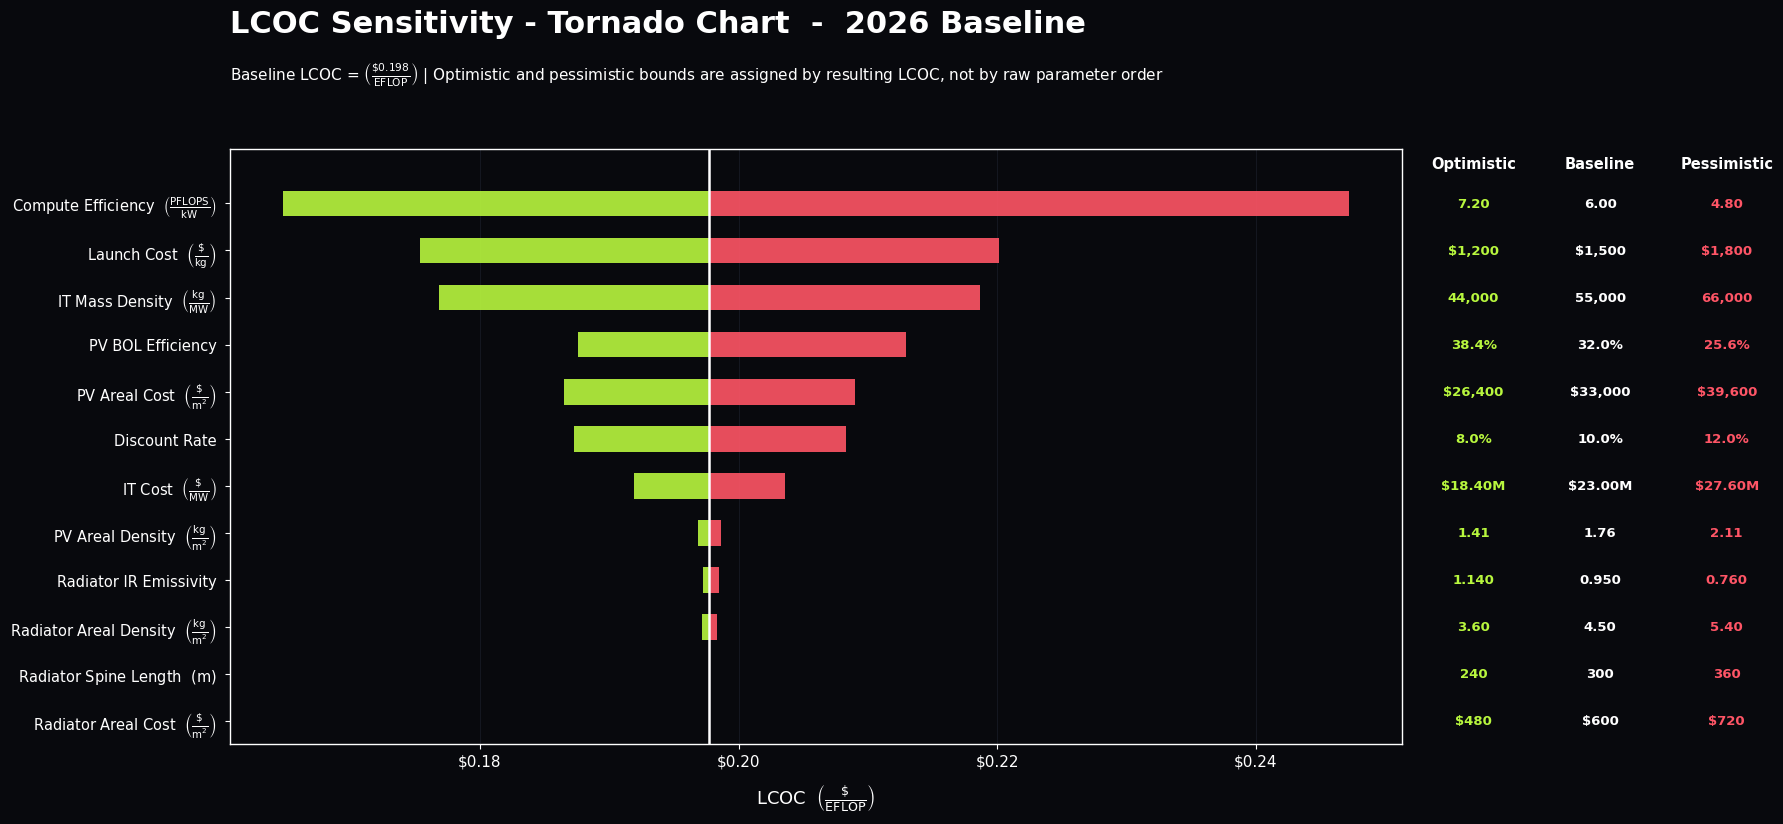

In [29]:
# Parameters to vary, with +/- range
PARAMS_TO_VARY = [
    ('Launch Cost  ' + r'$\left(\frac{\$}{\mathrm{kg}}\right)$',
    'launch_cost_per_kg', 0.20),
    ('Compute Efficiency  ' + r'$\left(\frac{\mathrm{PFLOPS}}{\mathrm{kW}}\right)$',
    'gamma_PFLOPS_per_kW', 0.20),
    ('IT Cost  ' + r'$\left(\frac{\$}{\mathrm{MW}}\right)$',
    'it_cost_per_MW', 0.20),
    ('PV Areal Cost  ' + r'$\left(\frac{\$}{\mathrm{m}^{2}}\right)$',
    'pv_areal_cost', 0.20),
    ('IT Mass Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{MW}}\right)$',
    'it_mass_density', 0.20),
    ('PV Areal Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{m}^{2}}\right)$',
    'pv_areal_mass', 0.20),
    ('Radiator Areal Cost  ' + r'$\left(\frac{\$}{\mathrm{m}^{2}}\right)$',
    'rad_areal_cost', 0.20),
    ('Discount Rate', 'discount_rate', 0.2),
    ('PV BOL Efficiency', 'pv_eff_BOL', 0.20),
    ('Radiator IR Emissivity', 'eps_IR', 0.2),
    ('Radiator Spine Length  ' + r'$\left(\mathrm{m}\right)$',
    'L_rad', 0.20),
    ('Radiator Areal Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{m}^{2}}\right)$',
    'rad_areal_mass', 0.20),
]


def format_param_value(attr, value):
    """Pretty formatter for the Optimistic / Baseline / Pessimistic value table."""
    if attr in ['discount_rate', 'pv_eff_BOL']:
        return f'{100 * value:.1f}%'
    if attr in ['eps_IR', 'alpha_solar_rad', 'F_earth']:
        return f'{value:.3f}'
    if attr in ['launch_cost_per_kg', 'rad_areal_cost', 'pv_areal_cost']:
        return f'${value:,.0f}'
    if attr == 'it_cost_per_MW':
        return f'${value / 1e6:.2f}M'
    if attr in ['it_mass_density']:
        return f'{value:,.0f}'
    if attr in ['pv_areal_mass', 'rad_areal_mass']:
        return f'{value:.2f}'
    if attr == 'gamma_PFLOPS_per_kW':
        return f'{value:.2f}'
    if attr == 'L_rad':
        return f'{value:.0f}'
    return f'{value:,.3g}'


base_lcoc = calculate_lcoc(BASELINE)['lcoc']

bars = []

for label, attr, delta in PARAMS_TO_VARY:
    base_val = getattr(BASELINE, attr)

    low_param_val = base_val * (1 - delta)
    high_param_val = base_val * (1 + delta)

    lcoc_low_param = calculate_lcoc(
        replace(BASELINE, **{attr: low_param_val})
    )['lcoc']

    lcoc_high_param = calculate_lcoc(
        replace(BASELINE, **{attr: high_param_val})
    )['lcoc']

    cases = [
        {
            'param_value': low_param_val,
            'lcoc': lcoc_low_param,
            'raw_side': 'low',
        },
        {
            'param_value': high_param_val,
            'lcoc': lcoc_high_param,
            'raw_side': 'high',
        },
    ]

    cases_sorted = sorted(cases, key=lambda d: d['lcoc'])

    optimistic_case = cases_sorted[0]
    pessimistic_case = cases_sorted[-1]

    optimistic_val = optimistic_case['param_value']
    pessimistic_val = pessimistic_case['param_value']

    optimistic_lcoc = optimistic_case['lcoc']
    pessimistic_lcoc = pessimistic_case['lcoc']

    swing = pessimistic_lcoc - optimistic_lcoc

    bars.append((
        label,
        attr,
        optimistic_lcoc,
        base_lcoc,
        pessimistic_lcoc,
        swing,
        optimistic_val,
        base_val,
        pessimistic_val,
    ))

# Sort by total LCOC swing magnitude
bars.sort(key=lambda x: x[5], reverse=True)


# -----------------------------------------------------------------------------
# Figure layout: main chart on left, value table on right
# -----------------------------------------------------------------------------

fig = plt.figure(figsize=(19, 8.5))

gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[7.0, 2.1],
    left=0.17,
    right=0.98,
    top=0.80,
    bottom=0.10,
    wspace=0.02,
)

ax = fig.add_subplot(gs[0, 0])
ax_tbl = fig.add_subplot(gs[0, 1])


# -----------------------------------------------------------------------------
# Tornado bars
# -----------------------------------------------------------------------------

bar_h = 0.55

for i, (
    label,
    attr,
    optimistic_lcoc,
    baseline_lcoc,
    pessimistic_lcoc,
    swing,
    optimistic_val,
    baseline_val,
    pessimistic_val,
) in enumerate(bars):

    # Optimistic case: lower LCOC side
    ax.barh(
        i,
        optimistic_lcoc - base_lcoc,
        left=base_lcoc,
        height=bar_h,
        color=ODC_COLOR,
        alpha=0.90,
        zorder=3,
    )

    # Pessimistic case: higher LCOC side
    ax.barh(
        i,
        pessimistic_lcoc - base_lcoc,
        left=base_lcoc,
        height=bar_h,
        color=ACCENT_R,
        alpha=0.90,
        zorder=3,
    )


# Baseline vertical line
ax.axvline(
    base_lcoc,
    color="#FFFFFF",
    linewidth=1.8,
    alpha=1.0,
    zorder=5,
)


# Use style_axes for axis styling, but draw title/subtitle manually
style_axes(
    ax,
    fig,
    title='',
    subtitle='',
    xlabel=r'LCOC  $\left(\frac{\$}{\mathrm{EFLOP}}\right)$',
    y_log=False,
    y_dollar=False,
    x_dollar=True,
)


# Manual title and subtitle with better spacing
fig.text(
    0.17,
    0.965,
    'LCOC Sensitivity - Tornado Chart  -  2026 Baseline',
    ha='left',
    va='top',
    fontsize=22,
    color="#FFFFFF",
    fontfamily=FONT,
    fontweight='bold',
)

fig.text(
    0.17,
    0.905,
    (
        fr'Baseline LCOC = $\left(\frac{{\${base_lcoc:.3f}}}{{\mathrm{{EFLOP}}}}\right)$'
        ' | Optimistic and pessimistic bounds are assigned by resulting LCOC, not by raw parameter order'
    ),
    ha='left',
    va='top',
    fontsize=11,
    color="#FFFFFF",
    alpha=1.0,
    fontfamily=FONT,
)


# Reapply categorical y-tick labels after style_axes
ax.set_yticks(range(len(bars)))

ax.set_yticklabels(
    [b[0] for b in bars],
    fontfamily=FONT,
    color="#FFFFFF",
    fontsize=10.5,
)

ax.tick_params(axis='x', colors="#FFFFFF")
ax.tick_params(axis='y', colors="#FFFFFF", pad=6)

for spine in ax.spines.values():
    spine.set_color("#FFFFFF")
    spine.set_alpha(1.0)

ax.grid(axis='y', alpha=0)
ax.grid(axis='x', color=GRID, alpha=0.45, linewidth=0.6)

# Largest swing at the top, with room for table header
ax.set_ylim(len(bars) - 0.5, -1.15)


# -----------------------------------------------------------------------------
# Right-side value table
# -----------------------------------------------------------------------------

ax_tbl.set_xlim(0, 1)
ax_tbl.set_ylim(len(bars) - 0.5, -1.15)
ax_tbl.axis('off')

table_x_optimistic = 0.16
table_x_base = 0.52
table_x_pessimistic = 0.88

header_y = -0.85

for x, header in [
    (table_x_optimistic, 'Optimistic'),
    (table_x_base, 'Baseline'),
    (table_x_pessimistic, 'Pessimistic'),
]:
    ax_tbl.text(
        x,
        header_y,
        header,
        ha='center',
        va='center',
        fontsize=10.5,
        color="#FFFFFF",
        fontfamily=FONT,
        fontweight='bold',
    )


for i, (
    label,
    attr,
    optimistic_lcoc,
    baseline_lcoc,
    pessimistic_lcoc,
    swing,
    optimistic_val,
    baseline_val,
    pessimistic_val,
) in enumerate(bars):

    ax_tbl.text(
        table_x_optimistic,
        i,
        format_param_value(attr, optimistic_val),
        ha='center',
        va='center',
        fontsize=9.5,
        color=ODC_COLOR,
        fontfamily=FONT,
        fontweight='bold',
    )

    ax_tbl.text(
        table_x_base,
        i,
        format_param_value(attr, baseline_val),
        ha='center',
        va='center',
        fontsize=9.5,
        color="#FFFFFF",
        fontfamily=FONT,
        fontweight='bold',
    )

    ax_tbl.text(
        table_x_pessimistic,
        i,
        format_param_value(attr, pessimistic_val),
        ha='center',
        va='center',
        fontsize=9.5,
        color=ACCENT_R,
        fontfamily=FONT,
        fontweight='bold',
    )


plt.show()

### 8c. LCOC vs launch cost sweep

How sensitive is LCOC to launch cost? Three solid/dashed curves at 2026, 2035, 2045 (under baseline learning rates) — each curve sweeps launch cost from \$50 to \$5000/kg while holding everything else at that year's evolved values. Markers show where the baseline launch-cost trajectory lands each year. Horizontal lines = TDC reference at the same year.

findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: Font family 'Poppins' not found.
findfont: F

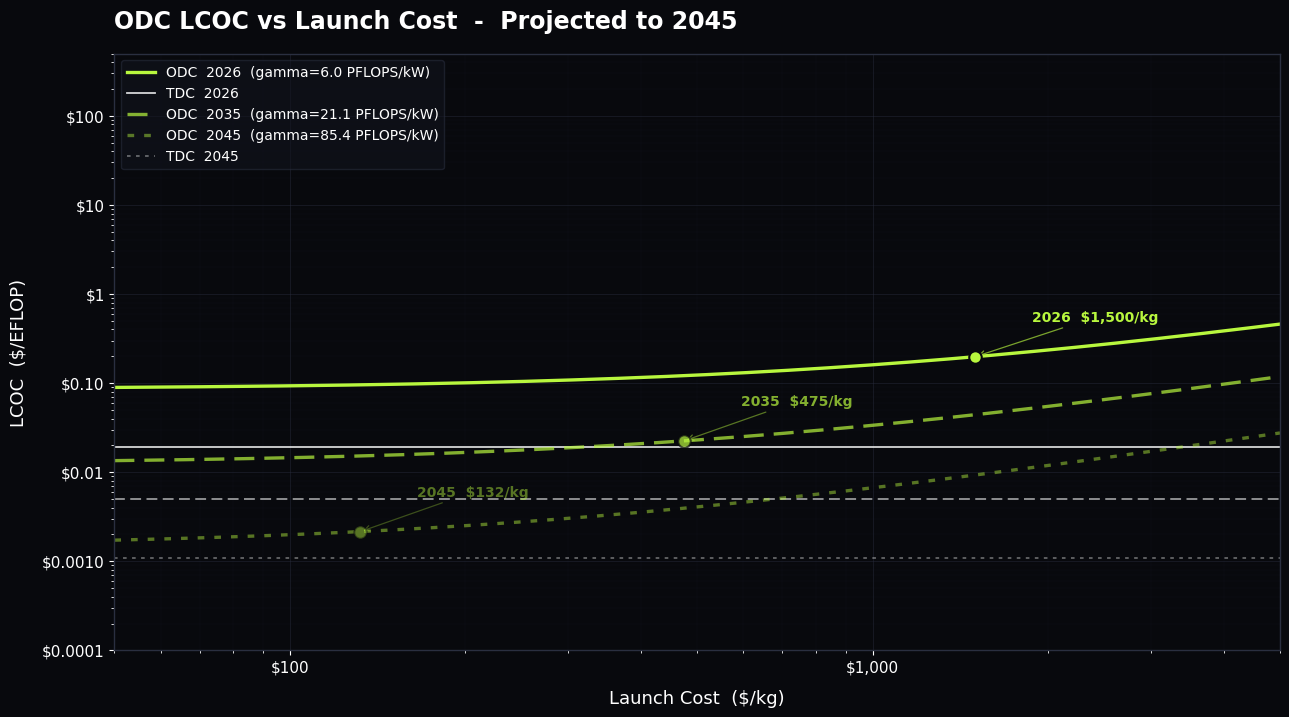

In [30]:
launch_costs  = np.logspace(np.log10(50), np.log10(5000), 200)
years_to_show = {'2026': 0, '2035': 9, '2045': 19}
line_alphas   = {'2026': 1.00, '2035': 0.70, '2045': 0.45}
line_styles   = {'2026': 'solid', '2035': (0,(6,3)), '2045': (0,(2,3))}

fig, ax = plt.subplots(figsize=(13, 7.5))

for yr_label, yo in years_to_show.items():
    ev_base = evolve_scenario(BASELINE, yo, LR_BASELINE)
    tdc_yr  = terrestrial_evolved(BASELINE.gamma_PFLOPS_per_kW, yo, LR_BASELINE)
    lcocs = np.array([
        calculate_lcoc(replace(ev_base, launch_cost_per_kg=lc))['lcoc']
        for lc in launch_costs
    ])
    a  = line_alphas[yr_label]
    ls = line_styles[yr_label]

    ax.plot(launch_costs, lcocs, color=ODC_COLOR, linewidth=2.4,
            linestyle=ls, alpha=a,
            label=f'ODC  {yr_label}  (gamma={ev_base.gamma_PFLOPS_per_kW:.1f} PFLOPS/kW)')

    nom_lc   = BASELINE.launch_cost_per_kg * (1 - LR_BASELINE.launch)**yo
    nom_lcoc = calculate_lcoc(replace(ev_base, launch_cost_per_kg=nom_lc))['lcoc']
    ax.plot(nom_lc, nom_lcoc, 'o', color=ODC_COLOR, markersize=9,
            alpha=a, zorder=10, markeredgecolor=BG, markeredgewidth=1.5)
    ax.annotate(f'{yr_label}  ${nom_lc:,.0f}/kg',
                xy=(nom_lc, nom_lcoc),
                xytext=(nom_lc * 1.25, nom_lcoc * 2.5),
                fontsize=10, color=ODC_COLOR, fontfamily=FONT,
                alpha=a, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=ODC_COLOR,
                                alpha=a*0.65, lw=0.9))

    ax.axhline(tdc_yr, color=TDC_COLOR, linewidth=1.3,
               linestyle=ls, alpha=a*0.85,
               label=f'TDC  {yr_label}' if yr_label in ('2026', '2045') else None)

leg = ax.legend(loc='upper left', frameon=True, framealpha=0.55,
                edgecolor=GRID, facecolor='#12141e',
                prop={'family': FONT, 'size': 10})
for t in leg.get_texts(): t.set_color(WHITE)

style_axes(ax, fig,
    title='ODC LCOC vs Launch Cost  -  Projected to 2045',
    # subtitle='Dashed = 2035 & 2045 projection at baseline learning rates  -  Circles = baseline launch cost that year  -  TDC reference lines',
    xlabel='Launch Cost  ($/kg)',
    ylabel='LCOC  ($/EFLOP)',
    x_log=True, y_log=True,
    xlim=(50, 5000), ylim=(0.0001, 500),
    x_dollar=True, y_dollar=True,
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 9. Summary

In [31]:
print('=' * 96)
print('SUMMARY: Orbital vs Terrestrial DC LCOC (2026-2045)')
print('=' * 96)
print(f'\nBaseline ODC parameters (locked initial values, 2026):')
print(f'  gamma           = {BASELINE.gamma_PFLOPS_per_kW} PFLOPS/kW')
print(f'  Launch          = ${BASELINE.launch_cost_per_kg:,.0f}/kg')
print(f'  PV eta_BOL      = {BASELINE.pv_eff_BOL}')
print(f'  PV areal cost   = ${BASELINE.pv_areal_cost:,.0f}/m^2')
print(f'  Rad areal cost  = ${BASELINE.rad_areal_cost:,.0f}/m^2')
print(f'  IT cost         = ${BASELINE.it_cost_per_MW/1e6:.1f}M/MW')
print(f'  alpha_solar     = {BASELINE.alpha_solar_rad}')
print(f'  alpha_IR        = {BASELINE.eps_IR}')
print(f'\nLearning-rate scenarios drive the uncertainty band on plots.')
print()

print(f'{"Year":>6s}  |   {"ODC range $/EFLOP":>32s}     {"TDC range $/EFLOP":>32s}  |  ratio')
print(f'{"":>6s}  |   {"(pes / base / opt)":>32s}     {"(pes / base / opt)":>32s}  |  (base)')
print('-' * 96)
for label, idx in [('2026', 0), ('2030', 4), ('2035', 9), ('2040', 14), ('2045', 19)]:
    odc_range = f'${odc_lo[idx]:.4f} / ${odc_nom[idx]:.4f} / ${odc_hi[idx]:.4f}'
    tdc_range = f'${tdc_lo[idx]:.4f} / ${tdc_nom[idx]:.4f} / ${tdc_hi[idx]:.4f}'
    print(f'{label:>6s}  |   {odc_range:>32s}     {tdc_range:>32s}  |  {odc_nom[idx]/tdc_nom[idx]:.2f}x')

print()
print('Cost breakdown for 2026 baseline ODC:')
for k, v in baseline_result['breakdown'].items():
    print(f'  {k:10s} ${v:.4f}/EFLOP   ({v/baseline_result["lcoc"]*100:5.1f}%)')

print()
print('Key takeaways:')
print('  - Initial parameter values are locked; only the learning rate varies.')
print('  - Launch cost decline drives the ODC trajectory; under baseline LR, launch falls')
print('    below ~$200/kg by 2045, narrowing the gap to TDC substantially.')
print('  - gamma improvement applies to both ODC and TDC equally and shifts both curves')
print('    down in parallel - it does not by itself close the ODC/TDC gap.')
print('  - PV areal cost ($33,000/m^2) and IT cost ($23M/MW) are now the second-tier')
print('    sensitivities behind launch.  See the tornado chart for confirmation.')

SUMMARY: Orbital vs Terrestrial DC LCOC (2026-2045)

Baseline ODC parameters (locked initial values, 2026):
  gamma           = 6.0 PFLOPS/kW
  Launch          = $1,500/kg
  PV eta_BOL      = 0.32
  PV areal cost   = $33,000/m^2
  Rad areal cost  = $600/m^2
  IT cost         = $23.0M/MW
  alpha_solar     = 0.05
  alpha_IR        = 0.95

Learning-rate scenarios drive the uncertainty band on plots.

  Year  |                  ODC range $/EFLOP                    TDC range $/EFLOP  |  ratio
        |                 (pes / base / opt)                   (pes / base / opt)  |  (base)
------------------------------------------------------------------------------------------------
  2026  |        $0.1978 / $0.1978 / $0.1978          $0.0194 / $0.0194 / $0.0194  |  10.21x
  2030  |        $0.1316 / $0.0747 / $0.0436          $0.0146 / $0.0106 / $0.0080  |  7.07x
  2035  |        $0.0792 / $0.0225 / $0.0070          $0.0103 / $0.0050 / $0.0026  |  4.53x
  2040  |        $0.0477 / $0.0069 / $0.

# Carbon Impact

In [ ]:
#!/usr/bin/env python3
"""
================================================================================
ODC vs TDC  --  end-to-end life-cycle carbon model  (GWP100)
================================================================================
One file, one knob: choose the data-center IT capacity at the top (or via
--capacity) and everything else sizes off it.

Pipeline
  1. Physical sizing      : PV array + single-horizontal-beam radiator (view-factor
                            self-consistent) + mass budget.
  2. TDC carbon           : embodied (IT / core-shell / MEP) with 5-yr IT refreshes
                            + grid operational carbon.
  3. ODC carbon           : launch (vehicle embodied amortized over reuse +
                            LOx/LCH4 production + combustion) + hardware embodied
                            (PV / radiator / IT, refreshed) + MEO-graveyard EOL.
  4. Comparison           : grid-intensity sweep (crossover) + capacity sweep
                            (launches, mass, totals).

Sources (see in-line comments):
  Alissa et al. 2025 Nature 641:331 (facility LCA); Falk et al. 2025
  arXiv:2509.00093 + NVIDIA HGX B200 PCF (IT embodied); Miraux 2022 (Starship
  vehicle/propellant); IAI 2023 (aluminium); Swart 2011 + Mohr 2007 (PV);
  BaSO4 coating + IAI (radiator).  Author sizing model for PV/radiator geometry.
================================================================================
"""
from __future__ import annotations
import argparse
import math
from dataclasses import dataclass, replace

import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ------------------------------------------------------------------ capacity --
CAPACITY_MW = 100.0          # <-- DEFAULT DC IT capacity; override with --capacity

# ----------------------------------------------------------------- constants --
I_SUN         = 1361.0       # solar constant [W/m^2]
SIGMA         = 5.670374419e-8
T_EARTH_EFF   = 254.15       # Earth effective radiating temp [K]  (NASA)
EARTH_ALBEDO  = 0.306        # (NASA)
FOOTBALL_M2   = 5350.0       # for human-scale prints


# ================================================================== scenario ==
@dataclass
class Scenario:
    # capacity / mission
    it_capacity_mw: float = CAPACITY_MW
    mission_years:  int   = 15
    it_refresh_years: int = 5

    # --- PV array ---
    pv_eff_BOL:   float = 0.32      # triple-junction GaAs BOL efficiency
    pv_derating:  float = 0.85      # wiring/mismatch/soiling-equivalent (PVWatts)
    pv_areal_mass: float = 1.76     # kg/m^2  (Spectrolab stack)
    pv_kgco2e_m2: float = 1400.0    # embodied, central (Swart 2011 + Mohr 2007)

    # --- radiator (single horizontal beam, double-sided) ---
    T_rad_C:        float = 80.0
    T_PV_C:         float = 80.0    # PV back-face temp seen by radiator
    L_rad:          float = 200.0   # fixed beam length [m]; width solved for
    eps_IR:         float = 0.95
    eps_PV_back:    float = 0.84
    alpha_solar_rad: float = 0.05
    F_earth:        float = 0.10
    rad_areal_mass: float = 9.2     # kg/m^2 (Reading B: BaSO4 coat 4.5 + Al 4.7)
    rad_kgco2e_m2:  float = 86.0    # embodied, central

    # --- IT (shared by ODC and TDC for apples-to-apples) ---
    it_mass_density:    float = 55_000.0   # kg/MW  (paper Table III)
    node_power_kw:      float = 10.4
    gpu_baseboard_kgco2e: float = 2274.0   # HGX B200 PCF
    host_server_kgco2e:   float = 1300.0

    # --- TDC facility / operation ---
    pue:              float = 1.12
    load_factor:      float = 1.0
    grid_intensity:   float = 0.40   # tCO2e/MWh == kgCO2e/kWh
    grid_decarb:      float = 0.0
    power_density_kw_m2: float = 2.0
    shell_kgco2e_m2:  float = 650.0
    mep_kgco2e_m2:    float = 400.0

    # --- ODC launch vehicle (Starship; Miraux 2022) ---
    sh_dry_t:    float = 275.0
    ss_dry_t:    float = 120.0
    n_raptor_sh: int   = 33
    n_raptor_ss: int   = 6
    raptor_mass_t: float = 1.6
    propellant_t: float = 4600.0
    o_f_ratio:   float = 3.6
    payload_cap_t: float = 100.0     # payload to LEO per launch
    n_sh_reuse:  float = 100.0
    n_ss_reuse:  float = 25.0
    ci_steel:    float = 6.0         # kgCO2e/kg stainless
    ci_engine:   float = 40.0        # kgCO2e/kg Ni-superalloy
    ci_prop_prod: float = 2.5        # kgCO2e/kg methalox (LOx+LCH4 production)
    combustion_ea_t: float = 4646.0  # tCO2e/launch (FAA EA; ascent+tests+landing)
    include_reentry: bool = False    # reused vehicle -> ~0 per delivery


def q_compute(s: Scenario) -> float:
    """Compute heat / power load [W]."""
    return s.it_capacity_mw * 1e6


# ============================================================ physical sizing ==
def F_perp_adjacent(h: float, w: float) -> float:
    """View factor: horizontal W x L plate -> perpendicular L x H plate sharing edge L.
    h = H/L, w = W/L. Howell/Siegel adjacent perpendicular rectangles.
    Verified: F_perp_adjacent(1, 1) ~ 0.20004."""
    H2W2 = h**2 + w**2
    a = ((1 + h**2) * (1 + w**2)) / (1 + H2W2)
    b = (w**2 * (1 + H2W2)) / ((1 + w**2) * H2W2)
    c = (h**2 * (1 + H2W2)) / ((1 + h**2) * H2W2)
    term = (h * np.arctan(1/h) + w * np.arctan(1/w)
            - np.sqrt(H2W2) * np.arctan(1/np.sqrt(H2W2))
            + 0.25 * np.log(a * b**(w**2) * c**(h**2)))
    return term / (np.pi * w)


def size_pv_array(s: Scenario) -> float:
    return q_compute(s) / (s.pv_eff_BOL * s.pv_derating * I_SUN)


def size_radiator(s: Scenario, verbose: bool = False) -> float:
    """Self-consistent radiator area for a single horizontal beam (double-sided).
    L = s.L_rad fixed; brentq solves width ratio w = W/L."""
    T_r  = s.T_rad_C + 273.15
    T_PV = s.T_PV_C  + 273.15
    A_PV = size_pv_array(s)
    H    = A_PV / (2 * s.L_rad)
    h    = H / s.L_rad
    L    = s.L_rad
    Q    = q_compute(s)

    def q_net(w):
        F_pv = F_perp_adjacent(h, w)
        q_ir = (2*s.eps_IR*SIGMA*T_r**4
                - 2*s.eps_IR*s.eps_PV_back*F_pv*SIGMA*T_PV**4
                - s.eps_IR*SIGMA*T_EARTH_EFF**4*s.F_earth)
        q_alb = s.alpha_solar_rad * EARTH_ALBEDO * I_SUN * s.F_earth
        return q_ir - q_alb

    resid = lambda w: q_net(w) * (w * L**2) - Q
    w_star = brentq(resid, 1e-4, 1e4)
    A_rad  = w_star * L**2

    if verbose:
        q = q_net(w_star); F_pv = F_perp_adjacent(h, w_star)
        print(f'  Geometry: L={L:.0f} m, H={H:.1f} m, h={h:.3f}, '
              f'W={w_star*L:.1f} m (w={w_star:.4f})')
        print(f'  F_PV (per face): {F_pv:.4f}   Net cooling: {q:.1f} W/m^2')
    return A_rad


def mass_budget(s: Scenario) -> dict:
    A_PV  = size_pv_array(s)
    A_rad = size_radiator(s)
    m_PV  = A_PV  * s.pv_areal_mass
    m_rad = A_rad * s.rad_areal_mass
    m_IT  = s.it_capacity_mw * s.it_mass_density
    return {'A_PV': A_PV, 'A_rad': A_rad,
            'PV': m_PV, 'Radiator': m_rad, 'IT': m_IT,
            'Total': m_PV + m_rad + m_IT}


# ================================================================ IT helpers ==
def it_quantities(s: Scenario) -> dict:
    nodes = s.it_capacity_mw * 1000.0 / s.node_power_kw
    gens  = math.ceil(s.mission_years / s.it_refresh_years)
    per_gen_t = nodes * (s.gpu_baseboard_kgco2e + s.host_server_kgco2e) / 1000.0
    return {'nodes': nodes, 'generations': gens,
            'per_gen_t': per_gen_t, 'all_gens_t': per_gen_t * gens}


# =================================================================== TDC model ==
def tdc_carbon(s: Scenario) -> dict:
    it = it_quantities(s)
    area = s.it_capacity_mw * 1000.0 / s.power_density_kw_m2
    shell = area * s.shell_kgco2e_m2 / 1000.0
    mep   = area * s.mep_kgco2e_m2   / 1000.0

    # year-by-year
    yrs = list(range(s.mission_years))
    emb = [0.0]*s.mission_years
    op  = [0.0]*s.mission_years
    emb[0] += shell + mep
    for g in range(it['generations']):
        yr = g*s.it_refresh_years
        if yr < s.mission_years:
            emb[yr] += it['per_gen_t']
    annual_mwh = s.it_capacity_mw * s.pue * s.load_factor * 8760.0
    for y in yrs:
        gi = s.grid_intensity * (1 - s.grid_decarb)**y
        op[y] = annual_mwh * gi

    emb_total = sum(emb); op_total = sum(op)
    return {
        'breakdown': {'IT (all gens)': it['all_gens_t'],
                      'Core & shell': shell, 'MEP': mep},
        'embodied_total': emb_total, 'operational_total': op_total,
        'total': emb_total + op_total,
        'floor_area_m2': area,
        'profile': {'years': yrs, 'embodied_spike': emb, 'operational': op,
                    'cum_embodied': np.cumsum(emb).tolist(),
                    'cum_operational': np.cumsum(op).tolist(),
                    'cum_total': np.cumsum(np.array(emb)+np.array(op)).tolist()},
    }


# =================================================================== ODC model ==
def odc_per_launch(s: Scenario) -> dict:
    """Per-launch carbon terms for a reused delivery vehicle [tCO2e]."""
    eng_sh = s.n_raptor_sh * s.raptor_mass_t
    eng_ss = s.n_raptor_ss * s.raptor_mass_t
    emb_sh = (s.sh_dry_t - eng_sh)*s.ci_steel + eng_sh*s.ci_engine
    emb_ss = (s.ss_dry_t - eng_ss)*s.ci_steel + eng_ss*s.ci_engine
    vehicle = emb_sh/s.n_sh_reuse + emb_ss/s.n_ss_reuse
    prop = s.ci_prop_prod * s.propellant_t
    comb = s.combustion_ea_t
    terms = {'Vehicle (amortized)': vehicle,
             'Propellant production': prop,
             'Combustion': comb}
    if s.include_reentry:
        terms['Re-entry'] = 13.2 * s.payload_cap_t  # NOx, Dirty Bits
    # detail for plotting
    detail = {
        'sh_struct': (s.sh_dry_t-eng_sh)*s.ci_steel/s.n_sh_reuse,
        'sh_eng':    eng_sh*s.ci_engine/s.n_sh_reuse,
        'ss_struct': (s.ss_dry_t-eng_ss)*s.ci_steel/s.n_ss_reuse,
        'ss_eng':    eng_ss*s.ci_engine/s.n_ss_reuse,
        'lox':  prop*0.5, 'methane': prop*0.5,
    }
    return {'terms': terms, 'per_launch_t': sum(terms.values()), 'detail': detail}


def odc_hardware_embodied(s: Scenario) -> dict:
    it = it_quantities(s)
    A_PV  = size_pv_array(s)
    A_rad = size_radiator(s)
    return {'IT (all gens)': it['all_gens_t'],
            'PV array':      A_PV  * s.pv_kgco2e_m2  / 1000.0,
            'Radiator':      A_rad * s.rad_kgco2e_m2 / 1000.0}


def odc_carbon(s: Scenario) -> dict:
    it = it_quantities(s)
    mb = mass_budget(s)
    pl = odc_per_launch(s)
    per_launch = pl['per_launch_t']

    it_mass = mb['IT']/1000.0  # tonnes
    cap = s.payload_cap_t

    n_init    = math.ceil(mb['Total']/1000.0 / cap)
    n_refresh_each = math.ceil(it_mass / cap)
    n_refresh_events = it['generations'] - 1
    n_launches = n_init + n_refresh_each*n_refresh_events

    launch_initial   = n_init * per_launch
    launch_refresh   = n_refresh_each * n_refresh_events * per_launch
    launch_total     = launch_initial + launch_refresh

    emb = odc_hardware_embodied(s)
    emb_total = sum(emb.values())

    # year profile
    yrs = list(range(s.mission_years))
    emb_spike = [0.0]*s.mission_years
    lau_spike = [0.0]*s.mission_years
    emb_spike[0] += emb['PV array'] + emb['Radiator']
    lau_spike[0] += launch_initial
    for g in range(it['generations']):
        yr = g*s.it_refresh_years
        if yr < s.mission_years:
            emb_spike[yr] += it['per_gen_t']
            if g > 0:
                lau_spike[yr] += n_refresh_each*per_launch
    cum_total = np.cumsum(np.array(emb_spike)+np.array(lau_spike)).tolist()

    return {
        'breakdown': emb,
        'launch_initial': launch_initial, 'launch_refresh': launch_refresh,
        'launch_total': launch_total, 'embodied_total': emb_total,
        'total': launch_total + emb_total,
        'n_launches': n_launches, 'n_init': n_init,
        'per_launch_t': per_launch, 'per_launch_detail': pl,
        'mass_budget': mb,
        'profile': {'years': yrs, 'embodied_spike': emb_spike,
                    'launch_spike': lau_spike, 'cum_total': cum_total},
    }


# ============================================================== visualization ==
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"axes.titlesize": 13, "axes.labelsize": 11,
                     "xtick.labelsize": 10, "ytick.labelsize": 10,
                     "axes.edgecolor": "#444", "figure.dpi": 120})
PAL = {"it": "#264653", "shell": "#6D6875", "mep": "#B5838D", "op": "#5B8E7D",
       "launch": "#E4572E", "launch2": "#F4A261", "pv": "#2A9D8F",
       "rad": "#8AB17D", "odc": "#E4572E", "tdc": "#264653",
       "steel": "#4C78A8", "engine": "#F58518", "lox": "#90BE6D", "ch4": "#F9C74F"}


def _despine(ax): sns.despine(ax=ax)


def plot_tdc(s: Scenario, tdc: dict, fname="carbon_figs/tdc_carbon.png"):
    p = tdc['profile']; yrs = np.array(p['years'])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

    # embodied breakdown bar
    items = sorted(tdc['breakdown'].items(), key=lambda x: x[1], reverse=True)
    cols = {'IT (all gens)': PAL['it'], 'Core & shell': PAL['shell'], 'MEP': PAL['mep']}
    ax1.bar([k for k,_ in items], [v/1000 for _,v in items],
            color=[cols[k] for k,_ in items], edgecolor="white")
    ax1.set_ylabel("ktCO2e"); ax1.set_title("(A) TDC embodied by subsystem", loc="left", fontweight="bold")
    for i,(k,v) in enumerate(items):
        ax1.text(i, v/1000, f"{v/1000:,.0f}", ha="center", va="bottom", fontsize=10)
    ax1.tick_params(axis='x', rotation=12); _despine(ax1)

    # cumulative embodied vs operational
    ax2.plot(yrs, np.array(p['cum_embodied'])/1000, "-o", color=PAL['it'], ms=5, label="Embodied")
    ax2.plot(yrs, np.array(p['cum_operational'])/1000, "-s", color=PAL['op'], ms=5, label="Operational")
    ax2.set_xlabel("Mission year"); ax2.set_ylabel("Cumulative ktCO2e")
    es = tdc['embodied_total']/tdc['total']; os_ = tdc['operational_total']/tdc['total']
    ax2.set_title(f"(B) Operational {os_:.0%} vs embodied {es:.0%}\n"
                  f"grid {s.grid_intensity:.2f} tCO2e/MWh", loc="left", fontweight="bold")
    ax2.legend(frameon=False, loc="upper left"); _despine(ax2)

    fig.suptitle(f"TDC carbon  -  {s.it_capacity_mw:g} MW, {s.mission_years} yr  "
                 f"(total {tdc['total']/1e6:.2f} MtCO2e)", fontsize=15, fontweight="bold")
    fig.tight_layout(rect=[0,0,1,0.95]); fig.savefig(fname, dpi=150, bbox_inches="tight")
    return fig


def plot_odc(s: Scenario, odc: dict, fname="carbon_figs/odc_carbon.png"):
    d = odc['per_launch_detail']['detail']; pl = odc['per_launch_t']
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 5.5),
                                        gridspec_kw={"width_ratios":[1.3,1,1.2]})

    # (A) per-launch stage stacked
    stages = {
        "Vehicle\n(amortized)": [("SH struct", d['sh_struct'], PAL['steel']),
                                 ("SH engines", d['sh_eng'], PAL['engine']),
                                 ("SS struct", d['ss_struct'], PAL['steel']),
                                 ("SS engines", d['ss_eng'], PAL['engine'])],
        "Propellant\nproduction": [("LOx", d['lox'], PAL['lox']),
                                   ("LCH4", d['methane'], PAL['ch4'])],
        "Combustion": [("EA (asc+test+land)", s.combustion_ea_t, PAL['launch'])],
    }
    xs = list(range(len(stages))); ymax = pl
    for i,(name, segs) in enumerate(stages.items()):
        bottom=0
        for lab,val,col in segs:
            ax1.bar(i, val, bottom=bottom, color=col, edgecolor="white", linewidth=0.6)
            if val > 0.03*ymax:
                ax1.text(i, bottom+val/2, f"{lab}\n{val:,.0f}", ha="center", va="center", fontsize=7)
            bottom+=val
        ax1.text(i, bottom+0.01*ymax, f"{bottom:,.0f} t", ha="center", va="bottom",
                 fontsize=9, fontweight="bold")
    ax1.set_xticks(xs); ax1.set_xticklabels(list(stages.keys()), fontsize=9)
    ax1.set_ylabel("tCO2e per launch")
    ax1.set_title(f"(A) Per-launch carbon\n{pl:,.0f} tCO2e ({pl/s.payload_cap_t:,.0f} kg/kg payload)",
                  loc="left", fontweight="bold"); _despine(ax1)

    # (B) vehicle embodied detail
    labels=["Super Heavy","Starship"]; struct=[d['sh_struct'],d['ss_struct']]; eng=[d['sh_eng'],d['ss_eng']]
    x=np.arange(2)
    ax2.bar(x, struct, color=PAL['steel'], edgecolor="white", label="Stainless")
    ax2.bar(x, eng, bottom=struct, color=PAL['engine'], edgecolor="white", label="Engines")
    ax2.set_xticks(x); ax2.set_xticklabels(labels)
    ax2.set_ylabel("tCO2e per launch (amortized)")
    ax2.set_title(f"(B) Vehicle embodied\n(N_SH={s.n_sh_reuse:.0f}, N_SS={s.n_ss_reuse:.0f} reuses)",
                  loc="left", fontweight="bold")
    ax2.legend(frameon=False, fontsize=9, loc="upper center", ncol=2); _despine(ax2)

    # (C) lifecycle breakdown
    comp = [("Launch: initial", odc['launch_initial'], PAL['launch']),
            ("Launch: refreshes", odc['launch_refresh'], PAL['launch2']),
            ("PV (embodied)", odc['breakdown']['PV array'], PAL['pv']),
            ("IT (embodied)", odc['breakdown']['IT (all gens)'], PAL['it']),
            ("Radiator (embodied)", odc['breakdown']['Radiator'], PAL['rad'])]
    comp.sort(key=lambda x:x[1], reverse=True)
    ax3.barh([c[0] for c in comp], [c[1]/1e6 for c in comp],
             color=[c[2] for c in comp], edgecolor="white")
    ax3.invert_yaxis(); ax3.set_xlabel("MtCO2e")
    ax3.set_title(f"(C) ODC lifecycle\n{odc['total']/1e6:.2f} Mt, "
                  f"launch {100*odc['launch_total']/odc['total']:.0f}%",
                  loc="left", fontweight="bold")
    for i,c in enumerate(comp):
        ax3.text(c[1]/1e6, i, f" {c[1]/1e6:.2f}", va="center", fontsize=9)
    _despine(ax3)

    fig.suptitle(f"ODC carbon  -  {s.it_capacity_mw:g} MW, {odc['n_launches']:.0f} launches",
                 fontsize=15, fontweight="bold")
    fig.tight_layout(rect=[0,0,1,0.94]); fig.savefig(fname, dpi=150, bbox_inches="tight")
    return fig


def plot_comparison(s: Scenario, fname="carbon_figs/comparison.png"):
    odc = odc_carbon(s); tdc = tdc_carbon(s)
    fig, ((axA, axB), (axC, axD)) = plt.subplots(2, 2, figsize=(15, 11))

    # (A) stacked totals
    for x, stack in [(0, [("Launch", odc['launch_total'], PAL['launch']),
                          ("Embodied", odc['embodied_total'], PAL['pv'])]),
                     (1, [("Operational", tdc['operational_total'], PAL['op']),
                          ("IT embodied", tdc['breakdown']['IT (all gens)'], PAL['it']),
                          ("Core & shell", tdc['breakdown']['Core & shell'], PAL['shell']),
                          ("MEP", tdc['breakdown']['MEP'], PAL['mep'])])]:
        bottom=0
        for name,val,col in stack:
            axA.bar(x, val/1e6, bottom=bottom/1e6, color=col, edgecolor="white", width=0.55)
            if val/1e6 > 0.04*max(odc['total'],tdc['total'])/1e6:
                axA.text(x,(bottom+val/2)/1e6, f"{name}\n{val/1e6:.2f}", ha="center", va="center",
                         fontsize=8.5, color="white")
            bottom+=val
        axA.text(x, bottom/1e6*1.01, f"{bottom/1e6:.2f} Mt", ha="center", va="bottom", fontweight="bold")
    axA.set_xticks([0,1]); axA.set_xticklabels(["ODC","TDC"]); axA.set_ylabel("MtCO2e")
    axA.set_title(f"(A) Lifecycle total @ grid {s.grid_intensity:.2f}\n"
                  f"ratio TDC/ODC = {tdc['total']/odc['total']:.2f}x", loc="left", fontweight="bold")
    _despine(axA)

    # (B) grid sweep crossover
    grid = np.linspace(0, 0.6, 120)
    tdc_curve = np.array([tdc_carbon(replace(s, grid_intensity=g))['total']
                          for g in grid]) / 1e6
    odc_flat = np.full_like(grid, odc['total']/1e6)
    axB.plot(grid, odc_flat, color=PAL['odc'], lw=2.5, label="ODC (grid-independent)")
    axB.plot(grid, tdc_curve, color=PAL['tdc'], lw=2.5, label="TDC (grid-driven)")
    ix = int(np.argmin(np.abs(tdc_curve - odc_flat))); gx = grid[ix]
    axB.axvline(gx, color="#888", ls="--", lw=1.2)
    axB.plot(gx, odc['total']/1e6, "o", color="k", ms=7, zorder=5)
    axB.annotate(f"crossover\n~{gx:.2f} tCO2e/MWh", (gx, odc['total']/1e6),
                 textcoords="offset points", xytext=(12,8), fontsize=10)
    for lab,gv in [("France ~0.05",0.05),("US avg ~0.37",0.37)]:
        axB.axvline(gv, color="#bbb", ls=":", lw=1)
        axB.text(gv, axB.get_ylim()[1]*0.95, lab, rotation=90, va="top", ha="right",
                 fontsize=8, color="#666")
    axB.set_xlabel("Grid carbon intensity (tCO2e/MWh)"); axB.set_ylabel("Lifecycle MtCO2e")
    axB.set_title("(B) Grid crossover\nODC wins above, TDC below", loc="left", fontweight="bold")
    axB.legend(frameon=False, loc="upper left"); _despine(axB)

    # capacity sweep: 1 -> 100 MW, LINEAR axes
    caps = np.arange(1, 101, dtype=float)
    n_launch=[]; mass_t=[]; odc_tot=[]; tdc_tot=[]
    for c in caps:
        sc = replace(s, it_capacity_mw=c)
        oc = odc_carbon(sc); tc = tdc_carbon(sc)
        n_launch.append(oc['n_launches']); mass_t.append(oc['mass_budget']['Total']/1000.0)
        odc_tot.append(oc['total']/1e6); tdc_tot.append(tc['total']/1e6)

    # (C) launches (staircase) + mass vs capacity -- linear
    lC = axC.plot(caps, n_launch, color=PAL['launch'], lw=2, drawstyle="steps-post",
                  label="ODC launches")
    axC.set_xlabel("IT capacity (MW)"); axC.set_ylabel("Number of launches", color=PAL['launch'])
    axC.tick_params(axis='y', labelcolor=PAL['launch'])
    axC2 = axC.twinx()
    lC2 = axC2.plot(caps, mass_t, color=PAL['pv'], lw=2.5, label="System mass")
    axC2.set_ylabel("System mass (t)", color=PAL['pv']); axC2.tick_params(axis='y', labelcolor=PAL['pv'])
    axC2.grid(False)
    axC.set_title("(C) Launches (staircase) & mass scale linearly with capacity",
                  loc="left", fontweight="bold")
    axC.legend(lC + lC2, [l.get_label() for l in lC + lC2], frameon=False,
               loc="upper left", fontsize=10)
    _despine(axC)

    # (D) totals vs capacity -- linear (straight lines = linear scaling)
    axD.plot(caps, odc_tot, color=PAL['odc'], lw=2.5, label="ODC")
    axD.plot(caps, tdc_tot, color=PAL['tdc'], lw=2.5, label="TDC")
    axD.set_xlabel("IT capacity (MW)"); axD.set_ylabel("Lifecycle MtCO2e")
    axD.set_title(f"(D) Totals vs capacity @ grid {s.grid_intensity:.2f}\n"
                  f"both linear; TDC/ODC ~ {tdc_tot[-1]/odc_tot[-1]:.1f}x constant",
                  loc="left", fontweight="bold")
    axD.legend(frameon=False, loc="upper left"); _despine(axD)

    fig.suptitle(f"ODC vs TDC  -  comparison (baseline {s.it_capacity_mw:g} MW)",
                 fontsize=16, fontweight="bold", y=0.995)
    fig.tight_layout(rect=[0,0,1,0.97]); fig.savefig(fname, dpi=150, bbox_inches="tight")
    return fig


# ----------------------------------------------------- emissions timelines ----
def _ramp(t, value, t0=-2.0, t1=0.0):
    """0 before t0; linear 0->value across [t0,t1]; constant `value` after."""
    return value * np.clip((t - t0) / (t1 - t0), 0.0, 1.0)


def _step(t, value, t_event):
    """0 before t_event; `value` at/after (cumulative step)."""
    return np.where(t >= t_event, value, 0.0)


def plot_timeline_odc(s: Scenario, odc: dict, fname="carbon_figs/odc_timeline.png"):
    """OWID-style stacked-area cumulative emissions over the mission.
    Pre-launch build ramps in on the left (years < 0); refreshes bump the top."""
    t = np.linspace(-2, s.mission_years, 600)
    it = it_quantities(s)
    per_gen = it['per_gen_t']
    n_ref_each = math.ceil((odc['mass_budget']['IT']/1000.0) / s.payload_cap_t)
    ref_launch = n_ref_each * odc['per_launch_t']
    refresh_yrs = [g*s.it_refresh_years for g in range(1, it['generations'])
                   if g*s.it_refresh_years < s.mission_years]

    launch_init = _ramp(t, odc['launch_initial'])
    pv  = _ramp(t, odc['breakdown']['PV array'])
    rad = _ramp(t, odc['breakdown']['Radiator'])
    it_cum = _ramp(t, per_gen) + sum(_step(t, per_gen, ry) for ry in refresh_yrs)
    lref   = sum(_step(t, ref_launch, ry) for ry in refresh_yrs)

    bands = [("Launch: initial", launch_init, PAL['launch']),
             ("PV (embodied)",   pv,  PAL['pv']),
             ("Radiator (embodied)", rad, PAL['rad']),
             ("IT (embodied, refreshes)", it_cum, PAL['it']),
             ("Launch: refreshes", lref, PAL['launch2'])]
    Y = np.vstack([b[1] for b in bands]) / 1e6
    total_top = Y.sum(axis=0)

    fig, ax = plt.subplots(figsize=(12, 6.5))
    ax.stackplot(t, Y, labels=[b[0] for b in bands],
                 colors=[b[2] for b in bands], alpha=0.95, edgecolor="white", lw=0.3)
    ax.axvspan(-2, 0, color="#ECECEC", zorder=0)
    ax.axvline(0, color="#444", lw=1.2, ls="--")
    ymax = total_top.max()
    ax.text(-1.0, ymax*0.5, "build /\npre-launch", ha="center", va="center",
            fontsize=10, color="#777", rotation=90)
    for ry in refresh_yrs:
        ax.axvline(ry, color="#888", ls=":", lw=1)
        ax.text(ry, ymax*0.99, "refresh", rotation=90, fontsize=8,
                color="#666", va="top", ha="right")
    ax.set_xlim(-2, s.mission_years); ax.set_ylim(0, ymax*1.05)
    ax.set_xlabel("Mission year"); ax.set_ylabel("Cumulative emissions (MtCO2e)")
    ax.set_title(f"ODC cumulative emissions timeline — {s.it_capacity_mw:g} MW "
                 f"(total {odc['total']/1e6:.2f} Mt)", fontweight="bold", loc="left")
    ax.legend(loc="lower right", frameon=False, fontsize=10)
    _despine(ax)
    fig.tight_layout(); fig.savefig(fname, dpi=150, bbox_inches="tight")
    return fig


def plot_timeline_tdc(s: Scenario, tdc: dict, fname="carbon_figs/tdc_timeline.png"):
    """OWID-style stacked-area cumulative emissions: embodied base + growing
    operational wedge (the grid term ramps linearly over the mission)."""
    t = np.linspace(-2, s.mission_years, 600)
    it = it_quantities(s)
    per_gen = it['per_gen_t']
    shell = tdc['breakdown']['Core & shell']; mep = tdc['breakdown']['MEP']
    op_total = tdc['operational_total']
    refresh_yrs = [g*s.it_refresh_years for g in range(1, it['generations'])
                   if g*s.it_refresh_years < s.mission_years]

    op_c    = np.where(t <= 0, 0.0, np.clip(t, 0, None)/s.mission_years * op_total)
    it_cum  = _ramp(t, per_gen) + sum(_step(t, per_gen, ry) for ry in refresh_yrs)
    shell_c = _ramp(t, shell)
    mep_c   = _ramp(t, mep)

    bands = [("Operational (grid)", op_c, PAL['op']),
             ("IT (embodied, refreshes)", it_cum, PAL['it']),
             ("Core & shell", shell_c, PAL['shell']),
             ("MEP", mep_c, PAL['mep'])]
    Y = np.vstack([b[1] for b in bands]) / 1e6
    total_top = Y.sum(axis=0)

    fig, ax = plt.subplots(figsize=(12, 6.5))
    ax.stackplot(t, Y, labels=[b[0] for b in bands],
                 colors=[b[2] for b in bands], alpha=0.95, edgecolor="white", lw=0.3)
    ax.axvspan(-2, 0, color="#ECECEC", zorder=0)
    ax.axvline(0, color="#444", lw=1.2, ls="--")
    ymax = total_top.max()
    ax.text(-1.0, ymax*0.5, "build", ha="center", va="center",
            fontsize=10, color="#777", rotation=90)
    for ry in refresh_yrs:
        ax.axvline(ry, color="#888", ls=":", lw=1)
        ax.text(ry, ymax*0.99, "IT refresh", rotation=90, fontsize=8,
                color="#666", va="top", ha="right")
    ax.set_xlim(-2, s.mission_years); ax.set_ylim(0, ymax*1.05)
    ax.set_xlabel("Mission year"); ax.set_ylabel("Cumulative emissions (MtCO2e)")
    ax.set_title(f"TDC cumulative emissions timeline — {s.it_capacity_mw:g} MW "
                 f"(total {tdc['total']/1e6:.2f} Mt)", fontweight="bold", loc="left")
    ax.legend(loc="upper left", frameon=False, fontsize=10)
    _despine(ax)
    fig.tight_layout(); fig.savefig(fname, dpi=150, bbox_inches="tight")
    return fig


# ===================================================================== driver ==
def run(capacity_mw: float, make_plots: bool = True):
    s = replace(Scenario(), it_capacity_mw=capacity_mw)
    print("="*70)
    print(f"CARBON MODEL  -  {capacity_mw:g} MW IT, {s.mission_years} yr mission, "
          f"grid {s.grid_intensity:.2f} tCO2e/MWh")
    print("="*70)

    # sizing
    print("\nPHYSICAL SIZING")
    A_PV = size_pv_array(s)
    print(f"  PV array : {A_PV:>12,.0f} m^2  ({A_PV/FOOTBALL_M2:.1f} football fields)")
    A_rad = size_radiator(s, verbose=True)
    print(f"  Radiator : {A_rad:>12,.0f} m^2  ({A_rad/FOOTBALL_M2:.1f} football fields)")
    mb = mass_budget(s)
    print("  Mass budget (t): " + ", ".join(f"{k} {mb[k]/1000:,.0f}"
          for k in ['PV','Radiator','IT','Total']))

    # TDC
    tdc = tdc_carbon(s)
    print("\nTDC CARBON (tCO2e)")
    for k,v in tdc['breakdown'].items(): print(f"  {k:<16}: {v:>12,.0f}")
    print(f"  {'Embodied total':<16}: {tdc['embodied_total']:>12,.0f}")
    print(f"  {'Operational':<16}: {tdc['operational_total']:>12,.0f}")
    print(f"  {'TOTAL':<16}: {tdc['total']:>12,.0f}  ({tdc['total']/1e6:.2f} Mt)")

    # ODC
    odc = odc_carbon(s)
    print("\nODC CARBON (tCO2e)")
    print(f"  Launches: {odc['n_launches']:.0f}  @ {odc['per_launch_t']:,.0f} t/launch")
    print(f"  {'Launch initial':<16}: {odc['launch_initial']:>12,.0f}")
    print(f"  {'Launch refresh':<16}: {odc['launch_refresh']:>12,.0f}")
    for k,v in odc['breakdown'].items(): print(f"  {k:<16}: {v:>12,.0f}")
    print(f"  {'TOTAL':<16}: {odc['total']:>12,.0f}  ({odc['total']/1e6:.2f} Mt)")
    print(f"\n  ODC/TDC ratio @ grid {s.grid_intensity:.2f}: {odc['total']/tdc['total']:.2f}x")

    if make_plots:
        plot_tdc(s, tdc); plot_odc(s, odc); plot_comparison(s)
        plot_timeline_tdc(s, tdc); plot_timeline_odc(s, odc)
        print("\nFigures written: tdc_carbon.png, odc_carbon.png, comparison.png, "
              "tdc_timeline.png, odc_timeline.png")
    return s, tdc, odc


if __name__ == "__main__":
    ap = argparse.ArgumentParser(description="ODC vs TDC carbon model")
    ap.add_argument("--capacity", type=float, default=CAPACITY_MW, help="IT capacity in MW")
    ap.add_argument("--no-plots", action="store_true")
    args = ap.parse_args()
    print(f"Verification: F_perp_adjacent(1,1) = {F_perp_adjacent(1,1):.5f} (expect 0.20004)")
    run(args.capacity, make_plots=not args.no_plots)